# CatBoost Workspace

Отдельный ноутбук только для CatBoost.

Здесь используется изолированный модуль `model_baselines_catboost.py`, чтобы не тянуть Naive, ARIMA, SARIMA, N-BEATS и LSTM.

Поток работы:
1. загрузка и очистка данных,
2. настройка CatBoost и профиля поиска,
3. `HalvingGridSearchCV` + финальное обучение,
4. rolling 24h benchmark на minute-данных,
5. экспорт результатов.

## 1) Окружение

При необходимости раскомментируй установку пакетов и перезапусти kernel.

In [45]:
# %pip install pandas numpy requests statsmodels matplotlib seaborn scikit-learn torch tqdm catboost

import sys
print('Python:', sys.version)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


## 2) Импорты и базовая конфигурация

Подключаем проект, включаем изолированный CatBoost-модуль и задаём общие параметры запуска.

In [46]:
import importlib

import os

from pathlib import Path

import numpy as np

import pandas as pd

import seaborn as sns

import torch

import data_pipeline as _dp

import model_baselines_catboost as _mb

from export_utils import plot_result

_dp = importlib.reload(_dp)
_mb = importlib.reload(_mb)

DataConfig = _dp.DataConfig
DataProcessor = _dp.DataProcessor
build_datasets = _dp.build_datasets
load_klines_from_sqlite = _dp.load_klines_from_sqlite
load_market_snapshots_from_sqlite = _dp.load_market_snapshots_from_sqlite
sync_market_data_to_sqlite = _dp.sync_market_data_to_sqlite

run_catboost = _mb.run_catboost
run_catboost_gridsearchcv_native_pipeline = _mb.run_catboost_gridsearchcv_native_pipeline
fit_catboost_inference_model = _mb.fit_catboost_inference_model
predict_catboost_inference = _mb.predict_catboost_inference

CPU_COUNT = int(os.cpu_count() or 8)
SAFE_CPU_WORKERS = max(1, min(16, CPU_COUNT - 1))

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='1',
    bars=100_000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)

SYMBOLS = ['BTCUSDT', 'ETHUSDT']

OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SQLITE_DB_PATH = Path('data/market_data.sqlite')

MARKET_SNAPSHOT_ROWS = 5

print('data_pipeline module file:', Path(_dp.__file__).resolve())
print('CatBoost module file:', Path(_mb.__file__).resolve())
print('SQLite DB:', SQLITE_DB_PATH.resolve())
print('CUDA available:', torch.cuda.is_available())

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

print('SAFE_CPU_WORKERS:', SAFE_CPU_WORKERS)
print(f'Data config: interval={CONFIG.interval}m | bars={CONFIG.bars:,}')

data_pipeline module file: C:\Users\zzz20\ModelLine\data_pipeline.py
CatBoost module file: C:\Users\zzz20\ModelLine\model_baselines_catboost.py
SQLite DB: C:\Users\zzz20\ModelLine\data\market_data.sqlite
CUDA available: True
GPU: NVIDIA GeForce RTX 4080
SAFE_CPU_WORKERS: 16
Data config: interval=1m | bars=100,000


## 3) Загрузка, очистка и разбиение данных

Скачиваем или читаем локальные ряды, затем очищаем и строим `full/train/test`.

In [47]:
raw_data = {}

processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)

cleaned_data = {}

reports = {}

latest_snapshot_rows = []



for symbol in SYMBOLS:

    try:

        synced_df, snapshot = sync_market_data_to_sqlite(

            symbol=symbol,

            config=CONFIG,

            db_path=SQLITE_DB_PATH,

            history_bars=CONFIG.bars,

            fetch_snapshot=True,

        )

        raw_data[symbol] = load_klines_from_sqlite(

            symbol=symbol,

            interval=CONFIG.interval,

            db_path=SQLITE_DB_PATH,

            limit=CONFIG.bars,

        )

        print(

            f'{symbol}: SQLite sync complete | history_rows={len(raw_data[symbol])} | '

            f'snapshot_ts={snapshot["snapshot_ts"] if snapshot is not None else "n/a"}'

        )

    except Exception as ex:

        cached_df = load_klines_from_sqlite(

            symbol=symbol,

            interval=CONFIG.interval,

            db_path=SQLITE_DB_PATH,

            limit=CONFIG.bars,

        )

        if len(cached_df) == 0:

            raise RuntimeError(

                f'{symbol}: не удалось синхронизировать данные в SQLite и в базе нет кэша. Ошибка: {ex}'

            )

        raw_data[symbol] = cached_df

        print(f'{symbol}: sync error ({ex}), использован SQLite cache rows={len(cached_df)}')



    snapshot_df = load_market_snapshots_from_sqlite(symbol=symbol, db_path=SQLITE_DB_PATH, limit=1)

    if len(snapshot_df) > 0:

        latest_snapshot_rows.append(snapshot_df.iloc[0].to_dict())



for symbol, df in raw_data.items():

    clean_df, rep = processor.process(df)

    cleaned_data[symbol] = clean_df

    reports[symbol] = rep

    print(

        f'{symbol}: before={rep["initial_rows"]} after={rep["final_rows"]} removed={rep["removed_total"]} '

        f'(zero/nonpos={rep["removed_nonpositive_or_zero"]}, outliers={rep["removed_outliers"]})'

    )



datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)

for symbol, data in datasets.items():

    print(f'{symbol}: full={len(data["full"])} train={len(data["train"])} test={len(data["test"])}')



LATEST_SNAPSHOT_DF = pd.DataFrame(latest_snapshot_rows)

if len(LATEST_SNAPSHOT_DF) > 0:

    LATEST_SNAPSHOT_DF['snapshot_ts'] = pd.to_datetime(LATEST_SNAPSHOT_DF['snapshot_ts'], utc=True)

    print('\nТекущий рынок из SQLite snapshot:')

    display(LATEST_SNAPSHOT_DF[['symbol', 'snapshot_ts', 'last_price', 'bid_price', 'ask_price', 'bid_size', 'ask_size', 'spread']])



cleaned_data['BTCUSDT'].head()

BTCUSDT: SQLite sync complete | history_rows=100000 | snapshot_ts=2026-03-09 10:20:02.117000+00:00
ETHUSDT: SQLite sync complete | history_rows=100000 | snapshot_ts=2026-03-09 10:20:04.827000+00:00
BTCUSDT: before=100000 after=99487 removed=513 (zero/nonpos=0, outliers=513)
ETHUSDT: before=100000 after=99289 removed=711 (zero/nonpos=0, outliers=711)
BTCUSDT: full=99487 train=79589 test=19898
ETHUSDT: full=99289 train=79431 test=19858

Текущий рынок из SQLite snapshot:


,symbol,snapshot_ts,last_price,bid_price,ask_price,bid_size,ask_size,spread
0,BTCUSDT,2026-03-09 10:20:02.117000+00:00,67828.90,67825.10,67825.2,3.113,0.016,0.10
1,ETHUSDT,2026-03-09 10:20:04.827000+00:00,2000.76,2000.79,2000.8,32.500,2.570,0.01


,start_ms,timestamp,open,high,low,close,volume,turnover
0,1767051600000,2025-12-29 23:40:00+00:00,87137.3,87144.4,87132.0,87144.3,13.424,1.169729e+06
1,1767051660000,2025-12-29 23:41:00+00:00,87144.3,87161.8,87137.5,87146.7,37.590,3.275950e+06
2,1767051720000,2025-12-29 23:42:00+00:00,87146.7,87182.4,87146.6,87164.0,14.535,1.266973e+06
3,1767051780000,2025-12-29 23:43:00+00:00,87164.0,87172.3,87164.0,87172.3,2.460,2.144350e+05
4,1767051840000,2025-12-29 23:44:00+00:00,87172.3,87175.4,87171.3,87171.3,4.237,3.693533e+05


## 4) Конфиг эксперимента CatBoost

Здесь меняются символ, профиль поиска, scoring и параметры rolling benchmark.

In [48]:
from sklearn.model_selection import ParameterGrid

RUN_SYMBOL = 'BTCUSDT'
RUN_MODEL = 'catboost'

CATBOOST_GRID_PROFILE = 'balanced'  # quick | balanced | full
CATBOOST_SCORING = 'MAE'
CATBOOST_TIME_WEIGHT = 0.05
CATBOOST_USE_CUDA = bool(torch.cuda.is_available())
CATBOOST_GRID_N_JOBS = 1
CATBOOST_CV_SPLITS = 2
CATBOOST_HALVING_FACTOR = 4
CATBOOST_SEARCH_MIN_POINTS = 512
CATBOOST_SEARCH_MAX_POINTS = 4_096
CATBOOST_TUNING_POINTS = 16_384  # последние N точек только для подбора; финальная модель ниже обучается на полном train

LIVE_MONITOR_ENABLED = True
LIVE_TRAIN_MINUTES = 40_000
LIVE_FORECAST_HORIZON_MINUTES = 60
LIVE_RETRAIN_EVERY_MINUTES = 60
LIVE_SYNC_BUFFER = 240
LIVE_POLL_SECONDS = 60
LIVE_MAX_CYCLES = None  # None = endless loop until interrupted manually
LIVE_FORCE_CPU = False

# Trading fee config. Percent values are expressed in pct units, not fractions.
LIVE_MARKET_TYPE = 'perpetual_futures'  # spot | perpetual_futures | options
LIVE_FEE_SCHEDULES = {
    'spot': {'taker_pct': 0.10, 'maker_pct': 0.10},
    'perpetual_futures': {'taker_pct': 0.06, 'maker_pct': 0.01},
    'options': {'taker_pct': 0.03, 'maker_pct': 0.03},
}
if LIVE_MARKET_TYPE not in LIVE_FEE_SCHEDULES:
    raise ValueError(f'Unknown LIVE_MARKET_TYPE: {LIVE_MARKET_TYPE}')
LIVE_FEE_CONFIG = LIVE_FEE_SCHEDULES[LIVE_MARKET_TYPE]
LIVE_MAX_SIDE_FEE_PCT = float(max(LIVE_FEE_CONFIG['taker_pct'], LIVE_FEE_CONFIG['maker_pct']))
LIVE_ROUND_TRIP_COST_PCT = float(LIVE_MAX_SIDE_FEE_PCT * 2.0)  # max fee on entry + max fee on exit
LIVE_MIN_EDGE_PCT = 0.08         # minimum net edge after costs to allow entry
LIVE_CONFIRM_1M_PCT = 0.01       # 1-minute forecast must confirm direction
LIVE_STOP_LOSS_PCT = 0.35
LIVE_TAKE_PROFIT_PCT = 0.60
LIVE_SIGNAL_HORIZONS = [1, 5, 10, 15, 30, 60]
LIVE_PULLBACK_ENTRY_PCT = 0.03   # short-term pullback magnitude before recovery
LIVE_REVERSAL_CONFIRM_PCT = 0.05 # medium horizon must reverse enough to treat as dip/rally entry
LIVE_ENTRY_MIN_MOVE_PCT = 0.03   # минимальный модуль 60m-прогноза, ниже которого вход не рассматривается
LIVE_ENTRY_RELATIVE_STRENGTH = 0.75  # адаптивный порог как доля от типичного масштаба прогнозов 10m/30m/60m
LIVE_EFFECTIVE_COST_CAP_RATIO = 0.50  # для слабых моделей не учитывать в signal gate весь round-trip cost целиком
LIVE_PULLBACK_FRACTION_OF_REQUIRED = 0.50  # pullback-порог как доля от адаптивного required_move
LIVE_REVERSAL_FRACTION_OF_REQUIRED = 0.50  # reversal-порог как доля от адаптивного required_move

PAPER_TRADING_ENABLED = True
PAPER_LEVERAGE = 1.0
PAPER_INITIAL_CAPITAL = 10_000.0
PAPER_ENTRY_FRACTION = 0.10
PAPER_DCA_FRACTION = 0.10
PAPER_MAX_DCA_COUNT = 3
PAPER_DCA_STEP_PCT = 0.20
PAPER_CLOSE_ON_SIGNAL_FLIP = True
PAPER_CLOSE_ON_MODEL_EXPIRY = True

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

if CATBOOST_TUNING_POINTS is None or int(CATBOOST_TUNING_POINTS) <= 0:
    tuning_full = full.reset_index(drop=True)
else:
    tuning_full = full.iloc[-min(len(full), int(CATBOOST_TUNING_POINTS)):].reset_index(drop=True)

ALL_RESULTS = {}
TRAINED_MODELS = {}

def _compute_signal_thresholds(horizon_forecasts: dict[str, float]) -> dict[str, float]:
    scale_values = [
        abs(float(horizon_forecasts.get(f'move_{int(horizon)}m_pct', float('nan'))))
        for horizon in [10, 30, 60]
    ]
    scale_values = [value for value in scale_values if np.isfinite(value)]

    forecast_scale_pct = float(np.median(scale_values)) if len(scale_values) > 0 else 0.0
    required_move_pct = float(max(LIVE_ENTRY_MIN_MOVE_PCT, forecast_scale_pct * LIVE_ENTRY_RELATIVE_STRENGTH))
    effective_cost_pct = float(min(LIVE_ROUND_TRIP_COST_PCT, required_move_pct * LIVE_EFFECTIVE_COST_CAP_RATIO))
    entry_trigger_move_pct = float(max(required_move_pct, effective_cost_pct))
    adaptive_pullback_pct = float(max(LIVE_PULLBACK_ENTRY_PCT * 0.50, required_move_pct * LIVE_PULLBACK_FRACTION_OF_REQUIRED))
    adaptive_reversal_pct = float(max(LIVE_CONFIRM_1M_PCT, min(LIVE_REVERSAL_CONFIRM_PCT, required_move_pct * LIVE_REVERSAL_FRACTION_OF_REQUIRED)))

    return {
        'forecast_scale_pct': forecast_scale_pct,
        'required_move_pct': required_move_pct,
        'effective_cost_pct': effective_cost_pct,
        'entry_trigger_move_pct': entry_trigger_move_pct,
        'adaptive_pullback_pct': adaptive_pullback_pct,
        'adaptive_reversal_pct': adaptive_reversal_pct,
    }

def _singleton_grid(anchor):
    return {key: [value] for key, value in anchor.items()}

def _non_anchor_values(values, anchor_value):
    return [value for value in values if value != anchor_value]

def _build_catboost_coverage_grid(full_values, anchor):
    blocks = [
        {**_singleton_grid(anchor), 'context_len': _non_anchor_values(full_values['context_len'], anchor['context_len'])},
        {**_singleton_grid(anchor), 'depth': _non_anchor_values(full_values['depth'], anchor['depth'])},
        {**_singleton_grid(anchor), 'learning_rate': _non_anchor_values(full_values['learning_rate'], anchor['learning_rate'])},
        {**_singleton_grid(anchor), 'iterations': _non_anchor_values(full_values['iterations'], anchor['iterations'])},
        {**_singleton_grid(anchor), 'l2_leaf_reg': _non_anchor_values(full_values['l2_leaf_reg'], anchor['l2_leaf_reg'])},
        _singleton_grid(anchor),
    ]
    return [block for block in blocks if all(len(values) > 0 for values in block.values())]

GRID_PROFILES = {
    'quick': {
        'context_len': [72],
        'depth': [6],
        'learning_rate': [0.05],
        'iterations': [160],
        'l2_leaf_reg': [3.0],
        'use_cuda': [CATBOOST_USE_CUDA],
    },
    'balanced': [
        {
            'context_len': [72, 120, 168],
            'depth': [8],
            'learning_rate': [0.04],
            'iterations': [280],
            'l2_leaf_reg': [3.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
        {
            'context_len': [120],
            'depth': [6, 8, 10],
            'learning_rate': [0.04],
            'iterations': [280],
            'l2_leaf_reg': [3.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
        {
            'context_len': [120],
            'depth': [8],
            'learning_rate': [0.03, 0.04, 0.05],
            'iterations': [160, 280, 420],
            'l2_leaf_reg': [3.0, 5.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
    ],
    'full': _build_catboost_coverage_grid(
        full_values={
            'context_len': [72, 120, 168],
            'depth': [6, 8, 10],
            'learning_rate': [0.03, 0.04, 0.05],
            'iterations': [160, 280, 420],
            'l2_leaf_reg': [3.0, 5.0],
        },
        anchor={
            'context_len': 120,
            'depth': 8,
            'learning_rate': 0.04,
            'iterations': 280,
            'l2_leaf_reg': 3.0,
            'use_cuda': CATBOOST_USE_CUDA,
        },
    ),
}

if CATBOOST_GRID_PROFILE not in GRID_PROFILES:
    raise ValueError(f'Unknown CATBOOST_GRID_PROFILE: {CATBOOST_GRID_PROFILE}')

CATBOOST_PARAM_GRID = GRID_PROFILES[CATBOOST_GRID_PROFILE]
CATBOOST_PARAM_GRID_CANDIDATES = len(ParameterGrid(CATBOOST_PARAM_GRID))

print(f'RUN_SYMBOL={RUN_SYMBOL} | full={len(full)} | tuning_full={len(tuning_full)} | final_train={len(train)} | final_test={len(test)}')
print(f'CatBoost grid profile: {CATBOOST_GRID_PROFILE}')
print('CatBoost device:', torch.cuda.get_device_name(0) if CATBOOST_USE_CUDA else 'cpu')
print(
    f'CatBoost config: use_cuda={CATBOOST_USE_CUDA}, n_jobs={CATBOOST_GRID_N_JOBS}, ' +
    f'cv_splits={CATBOOST_CV_SPLITS}, candidates={CATBOOST_PARAM_GRID_CANDIDATES}'
)
print(
    f'CatBoost search: tuning_points={len(tuning_full)}, min_points={CATBOOST_SEARCH_MIN_POINTS}, ' +
    f'max_points={CATBOOST_SEARCH_MAX_POINTS}, factor={CATBOOST_HALVING_FACTOR}, ' +
    f'scoring={CATBOOST_SCORING}, time_weight={CATBOOST_TIME_WEIGHT}'
)
print(
    f'Live config: train_minutes={LIVE_TRAIN_MINUTES}, horizon_minutes={LIVE_FORECAST_HORIZON_MINUTES}, ' +
    f'retrain_every={LIVE_RETRAIN_EVERY_MINUTES}, poll_seconds={LIVE_POLL_SECONDS}, max_cycles={LIVE_MAX_CYCLES}'
)
print(
    f'Trading config: market_type={LIVE_MARKET_TYPE}, max_side_fee_pct={LIVE_MAX_SIDE_FEE_PCT}, ' +
    f'round_trip_cost_pct={LIVE_ROUND_TRIP_COST_PCT}, min_edge_pct={LIVE_MIN_EDGE_PCT}, ' +
    f'entry_min_move_pct={LIVE_ENTRY_MIN_MOVE_PCT}, confirm_1m_pct={LIVE_CONFIRM_1M_PCT}, ' +
    f'stop_loss_pct={LIVE_STOP_LOSS_PCT}, take_profit_pct={LIVE_TAKE_PROFIT_PCT}'
)
print(
    f'Signal horizons={LIVE_SIGNAL_HORIZONS}, pullback_entry_pct={LIVE_PULLBACK_ENTRY_PCT}, ' +
    f'reversal_confirm_pct={LIVE_REVERSAL_CONFIRM_PCT}, entry_relative_strength={LIVE_ENTRY_RELATIVE_STRENGTH}, ' +
    f'effective_cost_cap_ratio={LIVE_EFFECTIVE_COST_CAP_RATIO}'
)
print(
    f'Paper trading: enabled={PAPER_TRADING_ENABLED}, leverage={PAPER_LEVERAGE}, initial_capital={PAPER_INITIAL_CAPITAL}, ' +
    f'entry_fraction={PAPER_ENTRY_FRACTION}, dca_fraction={PAPER_DCA_FRACTION}, ' +
    f'max_dca={PAPER_MAX_DCA_COUNT}, dca_step_pct={PAPER_DCA_STEP_PCT}'
)
CATBOOST_PARAM_GRID

RUN_SYMBOL=BTCUSDT | full=99487 | tuning_full=16384 | final_train=79589 | final_test=19898
CatBoost grid profile: balanced
CatBoost device: NVIDIA GeForce RTX 4080
CatBoost config: use_cuda=True, n_jobs=1, cv_splits=2, candidates=24
CatBoost search: tuning_points=16384, min_points=512, max_points=4096, factor=4, scoring=MAE, time_weight=0.05
Live config: train_minutes=40000, horizon_minutes=60, retrain_every=60, poll_seconds=60, max_cycles=None
Trading config: market_type=perpetual_futures, max_side_fee_pct=0.06, round_trip_cost_pct=0.12, min_edge_pct=0.08, entry_min_move_pct=0.03, confirm_1m_pct=0.01, stop_loss_pct=0.35, take_profit_pct=0.6
Signal horizons=[1, 5, 10, 15, 30, 60], pullback_entry_pct=0.03, reversal_confirm_pct=0.05, entry_relative_strength=0.75, effective_cost_cap_ratio=0.5
Paper trading: enabled=True, leverage=1.0, initial_capital=10000.0, entry_fraction=0.1, dca_fraction=0.1, max_dca=3, dca_step_pct=0.2


[{'context_len': [72, 120, 168],
  'depth': [8],
  'learning_rate': [0.04],
  'iterations': [280],
  'l2_leaf_reg': [3.0],
  'use_cuda': [True]},
 {'context_len': [120],
  'depth': [6, 8, 10],
  'learning_rate': [0.04],
  'iterations': [280],
  'l2_leaf_reg': [3.0],
  'use_cuda': [True]},
 {'context_len': [120],
  'depth': [8],
  'learning_rate': [0.03, 0.04, 0.05],
  'iterations': [160, 280, 420],
  'l2_leaf_reg': [3.0, 5.0],
  'use_cuda': [True]}]

## 5) Подбор гиперпараметров и финальное обучение

Запускаем `HalvingGridSearchCV`, сохраняем лучшую конфигурацию и обучаем inference-модель CatBoost.

CatBoost HalvingGridSearchCV: train_points=13107 | test_points=3277 | n_splits=2 | min_resources=512 | max_resources=4096 | factor=4 | aggressive_elimination=True | scoring=MAE


CATBOOST HalvingGridSearchCV: 64fit [06:45,  6.33s/fit]                       


CatBoost HalvingGridSearchCV: best MAE=43.784689 | {'context_len': 120, 'depth': 8, 'iterations': 160, 'l2_leaf_reg': 5.0, 'learning_rate': 0.03, 'use_cuda': True}
CatBoost final fit: train_points=2048 (best halving resource window) | test_points=3277
CatBoost device: GPU
CatBoost tuning points: 16384
CatBoost final inference train points: 79589
CatBoost split info: {'full_points': 16384, 'train_points': 13107, 'test_points': 3277, 'test_ratio': 0.2, 'cv_n_splits': 2, 'min_resource_points': 512, 'max_resource_points': 4096, 'best_resource_points': 2048, 'halving_factor': 4, 'aggressive_elimination': True, 'time_weight': 0.05}
CatBoost best params: {'context_len': 120, 'depth': 8, 'iterations': 160, 'l2_leaf_reg': 5.0, 'learning_rate': 0.03, 'use_cuda': True}
CatBoost metrics: {'MAE': 29.272408600880695, 'RMSE': 43.26852041280256, 'MAPE': 0.043538535001333534}


,score,score_std,param_context_len,param_depth,param_learning_rate,param_iterations,param_l2_leaf_reg,iter,rank_test_score
0,43.784689,1.105328,120,8,0.03,160,5.0,2,1
1,43.890970,1.018859,120,8,0.03,160,3.0,2,2
2,44.068589,0.998485,120,8,0.03,160,5.0,0,3
3,44.068589,0.998485,120,8,0.03,160,5.0,1,3
4,44.093014,1.097821,120,8,0.03,160,3.0,0,5
5,44.093014,1.097821,120,8,0.03,160,3.0,1,5
6,44.138044,1.165480,120,10,0.04,280,3.0,0,7
7,44.138044,1.165480,120,10,0.04,280,3.0,1,7
8,44.231008,0.955578,120,8,0.04,160,5.0,0,9
9,44.231008,0.955578,120,8,0.04,160,5.0,1,9


,y_true,y_pred
0,68226.1,68199.029962
1,68194.5,68225.804255
2,68150.0,68192.698120
3,68164.8,68150.822198
4,68154.7,68165.668996


,y_true,y_pred
3272,67809.4,67910.063717
3273,67879.5,67806.702340
3274,67845.5,67883.427155
3275,67808.0,67843.785415
3276,67824.3,67809.468807


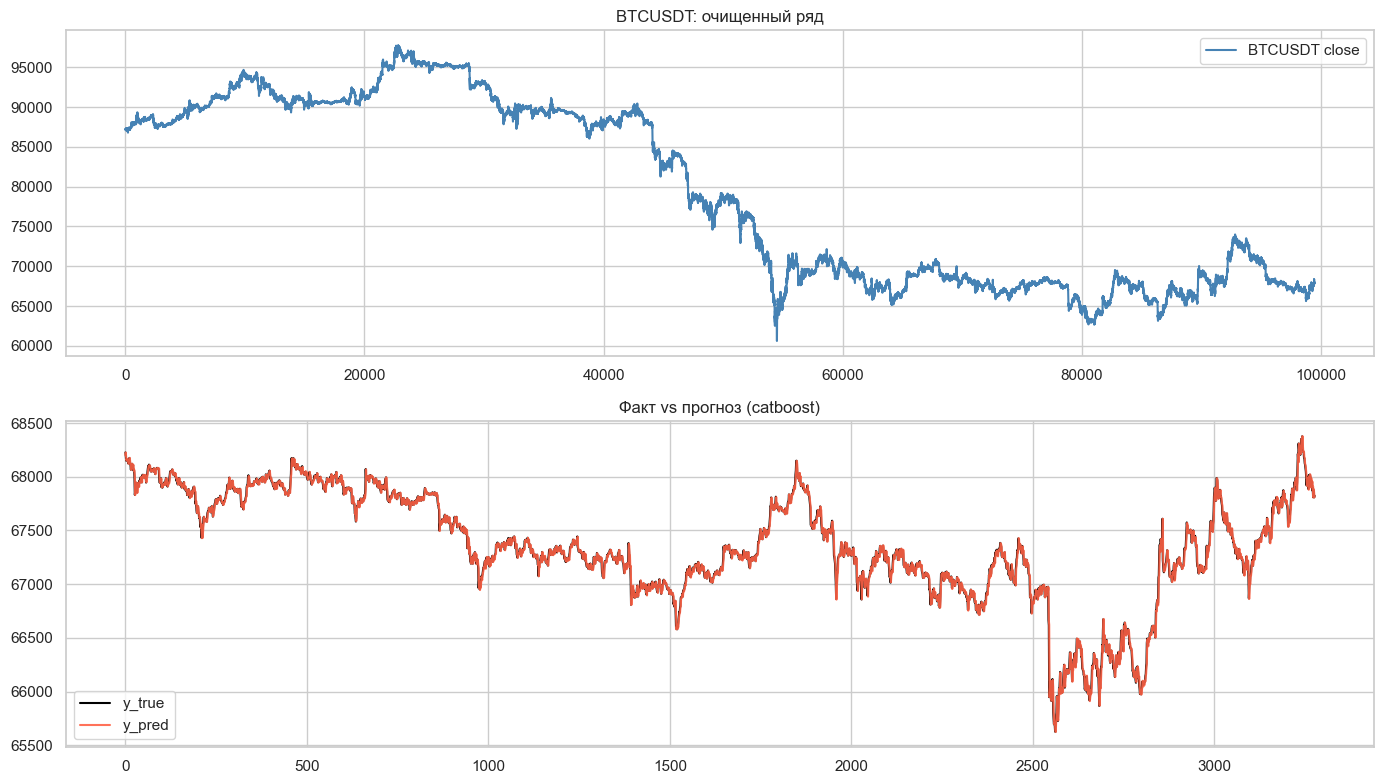

In [49]:
catboost_best_params, catboost_cv_df, model_metrics, pred_df, catboost_split_info = run_catboost_gridsearchcv_native_pipeline(
    full_series=tuning_full,
    param_grid=CATBOOST_PARAM_GRID,
    test_ratio=CONFIG.test_ratio,
    n_splits=CATBOOST_CV_SPLITS,
    scoring=CATBOOST_SCORING,
    use_cuda=CATBOOST_USE_CUDA,
    n_jobs=CATBOOST_GRID_N_JOBS,
    min_resource_points=CATBOOST_SEARCH_MIN_POINTS,
    max_resource_points=CATBOOST_SEARCH_MAX_POINTS,
    halving_factor=CATBOOST_HALVING_FACTOR,
    aggressive_elimination=True,
    time_weight=CATBOOST_TIME_WEIGHT,
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

TRAINED_MODELS[RUN_MODEL] = fit_catboost_inference_model(
    train,
    context_len=int(catboost_best_params['context_len']),
    depth=int(catboost_best_params['depth']),
    learning_rate=float(catboost_best_params['learning_rate']),
    iterations=int(catboost_best_params['iterations']),
    l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
    use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)),
)

cv_preview_cols = [
    col for col in [
        'score',
        'score_std',
        'param_context_len',
        'param_depth',
        'param_learning_rate',
        'param_iterations',
        'param_l2_leaf_reg',
        'iter',
        'rank_test_score',
    ] if col in catboost_cv_df.columns
]

print('CatBoost tuning points:', len(tuning_full))
print('CatBoost final inference train points:', len(train))
print('CatBoost split info:', catboost_split_info)
print('CatBoost best params:', catboost_best_params)
print('CatBoost metrics:', model_metrics)
display(catboost_cv_df[cv_preview_cols].head(20) if cv_preview_cols else catboost_cv_df.head(20))
display(pred_df.head())
display(pred_df.tail())
plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

## 6) Циклический live-мониторинг CatBoost

Модель обучается на последних 40 000 minute-баров и действует 60 минут.

Логика блока:
1. каждую минуту подтягиваем актуальные данные с Bybit в SQLite,
2. если с момента последнего обучения прошло 60 минут, обучаем новую модель,
3. каждую минуту пересчитываем прогноз на 60 минут вперёд на основе текущей цены,
4. сохраняем minute-by-minute лог: реальная цена, прогноз на 1 минуту, прогноз на 60 минут,
5. когда проходит час, считаем отклонение для прогнозов, у которых наступил target timestamp.

In [43]:
import time

from typing import Any

from IPython.display import clear_output, display

if not LIVE_MONITOR_ENABLED:

    print('Live monitor disabled (LIVE_MONITOR_ENABLED=False).')

else:

    def _prepare_minute_live_df(df: pd.DataFrame) -> pd.DataFrame:

        out = df.copy()

        out['timestamp'] = pd.to_datetime(out['timestamp'], errors='coerce', utc=True)

        out['close'] = pd.to_numeric(out['close'], errors='coerce')

        out = out.dropna(subset=['timestamp', 'close'])

        out = out[out['close'] > 0].copy()

        out = out.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)

        return out[['timestamp', 'close']]



    def _forecast_catboost_path(model_obj: dict[str, Any], history_series: pd.Series, horizon: int) -> pd.DataFrame:

        history_arr = pd.to_numeric(history_series, errors='coerce').dropna().astype(float).to_numpy()

        if len(history_arr) < 10:

            raise RuntimeError('Недостаточно истории для live-прогноза.')

        context = int(model_obj['context'])

        ret_mean = float(model_obj['ret_mean'])

        ret_std = float(model_obj['ret_std'])

        model = model_obj['model']

        history_log = list(np.log(np.clip(history_arr, 1e-8, None)).astype(float))

        history_ret_norm = list(((np.diff(np.log(np.clip(history_arr, 1e-8, None))) - ret_mean) / ret_std).astype(float))

        rows = []

        for step_idx in range(int(horizon)):

            if len(history_ret_norm) >= context:

                x_ctx = np.asarray(history_ret_norm[-context:], dtype=np.float32)

            else:

                first_val = history_ret_norm[0] if len(history_ret_norm) > 0 else 0.0

                pad = np.full((context - len(history_ret_norm),), first_val, dtype=np.float32)

                x_ctx = np.concatenate([pad, np.asarray(history_ret_norm, dtype=np.float32)])

            pred_ret_norm = float(model.predict(x_ctx.reshape(1, -1))[0])

            pred_ret = pred_ret_norm * ret_std + ret_mean

            pred_ret = float(np.clip(pred_ret, -0.20, 0.20))

            pred_log = float(history_log[-1] + pred_ret)

            pred_price = float(np.exp(pred_log))

            rows.append({'step_minute': int(step_idx + 1), 'pred_price': pred_price})

            history_log.append(pred_log)

            history_ret_norm.append(pred_ret_norm)

        return pd.DataFrame(rows)



    def _calc_move_pct(predicted_price: float, current_price: float) -> float:

        if not np.isfinite(predicted_price) or not np.isfinite(current_price) or float(current_price) == 0.0:

            return float('nan')

        return float((float(predicted_price) / float(current_price) - 1.0) * 100.0)



    def _extract_horizon_forecasts(forecast_path_df: pd.DataFrame, current_price: float, horizons: list[int]) -> dict[str, float]:

        out: dict[str, float] = {}

        for horizon in horizons:

            horizon_idx = max(0, min(int(horizon) - 1, len(forecast_path_df) - 1))

            pred_price = float(forecast_path_df['pred_price'].iloc[horizon_idx])

            out[f'pred_{int(horizon)}m'] = pred_price

            out[f'move_{int(horizon)}m_pct'] = _calc_move_pct(pred_price, current_price)

        return out



    def _build_trade_signal(current_price: float, horizon_forecasts: dict[str, float]) -> dict[str, Any]:

        move_1m_pct = float(horizon_forecasts.get('move_1m_pct', float('nan')))

        move_5m_pct = float(horizon_forecasts.get('move_5m_pct', float('nan')))

        move_10m_pct = float(horizon_forecasts.get('move_10m_pct', float('nan')))

        move_15m_pct = float(horizon_forecasts.get('move_15m_pct', float('nan')))

        move_30m_pct = float(horizon_forecasts.get('move_30m_pct', float('nan')))

        move_60m_pct = float(horizon_forecasts.get('move_60m_pct', float('nan')))

        thresholds = _compute_signal_thresholds(horizon_forecasts)
        forecast_scale_pct = float(thresholds['forecast_scale_pct'])
        required_move_pct = float(thresholds['required_move_pct'])
        effective_cost_pct = float(thresholds['effective_cost_pct'])
        entry_trigger_move_pct = float(thresholds['entry_trigger_move_pct'])
        adaptive_pullback_pct = float(thresholds['adaptive_pullback_pct'])
        adaptive_reversal_pct = float(thresholds['adaptive_reversal_pct'])

        long_edge_pct = float(move_60m_pct - effective_cost_pct)
        short_edge_pct = float((-move_60m_pct) - effective_cost_pct)

        signal = 'hold'

        signal_type = 'none'

        entry_price = float(current_price)

        stop_loss = float('nan')

        take_profit = float('nan')

        target_exit_price = float('nan')

        reason = f'adaptive edge below threshold: |move_60m| < {entry_trigger_move_pct:.3f}%'

        if all(np.isfinite(v) for v in [move_1m_pct, move_5m_pct, move_10m_pct, move_30m_pct, move_60m_pct]):

            trend_long = (
                move_60m_pct >= entry_trigger_move_pct
                and long_edge_pct >= 0.0
                and move_5m_pct >= 0.0
                and move_10m_pct >= LIVE_CONFIRM_1M_PCT
                and move_30m_pct > 0.0
            )

            trend_short = (
                (-move_60m_pct) >= entry_trigger_move_pct
                and short_edge_pct >= 0.0
                and move_5m_pct <= 0.0
                and move_10m_pct <= -LIVE_CONFIRM_1M_PCT
                and move_30m_pct < 0.0
            )

            dip_long = (
                move_60m_pct >= entry_trigger_move_pct
                and long_edge_pct >= 0.0
                and move_5m_pct <= -adaptive_pullback_pct
                and move_10m_pct >= adaptive_reversal_pct
                and move_30m_pct > 0.0
                and move_60m_pct > 0.0
            )

            rally_short = (
                (-move_60m_pct) >= entry_trigger_move_pct
                and short_edge_pct >= 0.0
                and move_5m_pct >= adaptive_pullback_pct
                and move_10m_pct <= -adaptive_reversal_pct
                and move_30m_pct < 0.0
                and move_60m_pct < 0.0
            )

            if dip_long:

                signal = 'long'

                signal_type = 'buy_dip'

                stop_loss = float(current_price * (1.0 - LIVE_STOP_LOSS_PCT / 100.0))

                take_profit = float(current_price * (1.0 + LIVE_TAKE_PROFIT_PCT / 100.0))

                target_exit_price = float(horizon_forecasts.get('pred_60m', current_price))

                reason = 'adaptive buy_dip: 5m pullback with 10m/30m/60m recovery'

            elif rally_short:

                signal = 'short'

                signal_type = 'sell_rally'

                stop_loss = float(current_price * (1.0 + LIVE_STOP_LOSS_PCT / 100.0))

                take_profit = float(current_price * (1.0 - LIVE_TAKE_PROFIT_PCT / 100.0))

                target_exit_price = float(horizon_forecasts.get('pred_60m', current_price))

                reason = 'adaptive sell_rally: 5m rally with 10m/30m/60m decline'

            elif trend_long:

                signal = 'long'

                signal_type = 'trend_long'

                stop_loss = float(current_price * (1.0 - LIVE_STOP_LOSS_PCT / 100.0))

                take_profit = float(current_price * (1.0 + LIVE_TAKE_PROFIT_PCT / 100.0))

                target_exit_price = float(horizon_forecasts.get('pred_60m', current_price))

                reason = 'adaptive trend_long: 10m/30m/60m aligned upward'

            elif trend_short:

                signal = 'short'

                signal_type = 'trend_short'

                stop_loss = float(current_price * (1.0 + LIVE_STOP_LOSS_PCT / 100.0))

                take_profit = float(current_price * (1.0 - LIVE_TAKE_PROFIT_PCT / 100.0))

                target_exit_price = float(horizon_forecasts.get('pred_60m', current_price))

                reason = 'adaptive trend_short: 10m/30m/60m aligned downward'

            else:

                reason = 'adaptive threshold passed partly, but path is not aligned for entry' if max(abs(move_60m_pct), 0.0) >= entry_trigger_move_pct else reason

        return {
            'signal': signal,
            'signal_type': signal_type,
            'entry_price': entry_price,
            'move_1m_pct': move_1m_pct,
            'move_5m_pct': move_5m_pct,
            'move_10m_pct': move_10m_pct,
            'move_15m_pct': move_15m_pct,
            'move_30m_pct': move_30m_pct,
            'move_60m_pct': move_60m_pct,
            'forecast_scale_pct': forecast_scale_pct,
            'required_move_pct': required_move_pct,
            'effective_cost_pct': effective_cost_pct,
            'entry_trigger_move_pct': entry_trigger_move_pct,
            'adaptive_pullback_pct': adaptive_pullback_pct,
            'adaptive_reversal_pct': adaptive_reversal_pct,
            'long_edge_pct': float(long_edge_pct),
            'short_edge_pct': float(short_edge_pct),
            'stop_loss': stop_loss,
            'take_profit': take_profit,
            'target_exit_price': target_exit_price,
            'reason': reason,
        }



    def _load_live_history(symbol: str, history_limit: int) -> tuple[pd.DataFrame, dict[str, Any] | None]:

        live_history_bars = int(history_limit + LIVE_FORECAST_HORIZON_MINUTES + LIVE_SYNC_BUFFER)

        live_config = DataConfig(
            base_url=CONFIG.base_url,
            interval='1',
            bars=live_history_bars,
            target_col=CONFIG.target_col,
            date_col=CONFIG.date_col,
            test_ratio=CONFIG.test_ratio,
        )

        _, live_snapshot = sync_market_data_to_sqlite(
            symbol=symbol,
            config=live_config,
            db_path=SQLITE_DB_PATH,
            history_bars=live_history_bars,
            fetch_snapshot=True,
        )

        live_raw = load_klines_from_sqlite(
            symbol=symbol,
            interval='1',
            db_path=SQLITE_DB_PATH,
            limit=live_history_bars,
        )

        live_df = _prepare_minute_live_df(live_raw)

        return live_df, live_snapshot



    def _position_unrealized_pnl(position: dict[str, Any] | None, current_price: float) -> float:

        if position is None:

            return 0.0

        qty = float(position['qty'])

        avg_entry = float(position['avg_entry_price'])

        if position['side'] == 'long':

            return float((current_price - avg_entry) * qty)

        return float((avg_entry - current_price) * qty)



    def _position_return_pct(position: dict[str, Any] | None, current_price: float) -> float:

        if position is None or float(position['avg_entry_price']) == 0.0:

            return float('nan')

        if position['side'] == 'long':

            return float((current_price / float(position['avg_entry_price']) - 1.0) * 100.0)

        return float((float(position['avg_entry_price']) / current_price - 1.0) * 100.0)



    def _position_levels(side: str, avg_entry_price: float) -> tuple[float, float]:

        if side == 'long':

            return (
                float(avg_entry_price * (1.0 - LIVE_STOP_LOSS_PCT / 100.0)),
                float(avg_entry_price * (1.0 + LIVE_TAKE_PROFIT_PCT / 100.0)),
            )

        return (
            float(avg_entry_price * (1.0 + LIVE_STOP_LOSS_PCT / 100.0)),
            float(avg_entry_price * (1.0 - LIVE_TAKE_PROFIT_PCT / 100.0)),
        )



    def _open_position(side: str, signal_type: str, current_price: float, current_ts: pd.Timestamp, target_exit_price: float, free_cash: float, fraction: float) -> dict[str, Any] | None:

        allocation_cash = float(min(free_cash, max(0.0, free_cash * float(fraction))))

        if allocation_cash <= 0.0 or current_price <= 0.0:

            return None

        qty = float((allocation_cash * PAPER_LEVERAGE) / current_price)

        stop_loss, take_profit = _position_levels(side, current_price)

        return {
            'side': side,
            'signal_type': signal_type,
            'opened_at': current_ts,
            'planned_exit_ts': current_ts + pd.Timedelta(minutes=LIVE_FORECAST_HORIZON_MINUTES),
            'avg_entry_price': float(current_price),
            'qty': qty,
            'margin_used': allocation_cash,
            'notional': float(qty * current_price),
            'dca_count': 0,
            'target_exit_price': float(target_exit_price),
            'stop_loss': float(stop_loss),
            'take_profit': float(take_profit),
            'entries': [
                {
                    'ts': current_ts,
                    'price': float(current_price),
                    'cash': allocation_cash,
                    'qty': qty,
                    'reason': 'initial_entry',
                }
            ],
        }



    def _add_to_position(position: dict[str, Any], current_price: float, current_ts: pd.Timestamp, free_cash: float, fraction: float, target_exit_price: float) -> tuple[dict[str, Any], float] | tuple[None, float]:

        allocation_cash = float(min(free_cash, max(0.0, free_cash * float(fraction))))

        if allocation_cash <= 0.0 or current_price <= 0.0:

            return None, 0.0

        add_qty = float((allocation_cash * PAPER_LEVERAGE) / current_price)

        new_qty = float(position['qty'] + add_qty)

        if new_qty <= 0.0:

            return None, 0.0

        new_avg = float((position['qty'] * position['avg_entry_price'] + add_qty * current_price) / new_qty)

        position['qty'] = new_qty

        position['avg_entry_price'] = new_avg

        position['margin_used'] = float(position['margin_used'] + allocation_cash)

        position['notional'] = float(position['qty'] * current_price)

        position['dca_count'] = int(position['dca_count'] + 1)

        if position['side'] == 'long':

            position['target_exit_price'] = float(max(position['target_exit_price'], target_exit_price)) if np.isfinite(target_exit_price) else float(position['target_exit_price'])

        else:

            position['target_exit_price'] = float(min(position['target_exit_price'], target_exit_price)) if np.isfinite(target_exit_price) else float(position['target_exit_price'])

        stop_loss, take_profit = _position_levels(position['side'], new_avg)

        position['stop_loss'] = float(stop_loss)

        position['take_profit'] = float(take_profit)

        position['entries'].append({
            'ts': current_ts,
            'price': float(current_price),
            'cash': allocation_cash,
            'qty': add_qty,
            'reason': f'dca_{position["dca_count"]}',
        })

        return position, allocation_cash



    def _close_position(position: dict[str, Any], current_price: float, current_ts: pd.Timestamp, reason: str) -> tuple[float, dict[str, Any]]:

        unrealized_pnl = _position_unrealized_pnl(position, current_price)

        released_cash = float(position['margin_used'] + unrealized_pnl)

        trade = {
            'side': position['side'],
            'signal_type': position['signal_type'],
            'opened_at': position['opened_at'],
            'closed_at': current_ts,
            'avg_entry_price': float(position['avg_entry_price']),
            'exit_price': float(current_price),
            'target_exit_price': float(position['target_exit_price']),
            'qty': float(position['qty']),
            'margin_used': float(position['margin_used']),
            'realized_pnl': float(unrealized_pnl),
            'return_pct': float(_position_return_pct(position, current_price)),
            'dca_count': int(position['dca_count']),
            'close_reason': reason,
        }

        return released_cash, trade



    def _should_dca(position: dict[str, Any] | None, signal: dict[str, Any], current_price: float) -> bool:

        if position is None or signal['signal'] != position['side']:

            return False

        if int(position['dca_count']) >= int(PAPER_MAX_DCA_COUNT):

            return False

        avg_entry = float(position['avg_entry_price'])

        step_threshold = float(PAPER_DCA_STEP_PCT * (int(position['dca_count']) + 1))

        if position['side'] == 'long':

            adverse_move_pct = float((current_price / avg_entry - 1.0) * 100.0)

            return adverse_move_pct <= -step_threshold

        adverse_move_pct = float((current_price / avg_entry - 1.0) * 100.0)

        return adverse_move_pct >= step_threshold



    forecast_journal = []

    live_rows = []

    active_model = None

    cycle_idx = 0

    paper_state = {
        'enabled': bool(PAPER_TRADING_ENABLED),
        'free_cash': float(PAPER_INITIAL_CAPITAL),
        'realized_pnl': 0.0,
        'position': None,
        'closed_trades': [],
    }

    try:

        while LIVE_MAX_CYCLES is None or cycle_idx < int(LIVE_MAX_CYCLES):

            cycle_idx += 1

            fit_started = False

            live_df, live_snapshot = _load_live_history(RUN_SYMBOL, LIVE_TRAIN_MINUTES)

            if len(live_df) < LIVE_TRAIN_MINUTES:

                raise RuntimeError(
                    f'Недостаточно данных для live-train: {len(live_df)} < {LIVE_TRAIN_MINUTES}. '
                    'Увеличь историю в SQLite или уменьши LIVE_TRAIN_MINUTES.'
                )

            current_ts = pd.Timestamp(live_df['timestamp'].iloc[-1]).floor('min')

            current_price = float(live_df['close'].iloc[-1])

            train_df = live_df.iloc[-LIVE_TRAIN_MINUTES:].reset_index(drop=True)

            train_series = train_df['close'].astype(float).reset_index(drop=True)

            needs_refit = active_model is None or current_ts >= active_model['expires_at']

            if needs_refit:

                fit_t0 = time.perf_counter()

                model_obj = fit_catboost_inference_model(
                    train_series,
                    context_len=int(catboost_best_params['context_len']),
                    depth=int(catboost_best_params['depth']),
                    learning_rate=float(catboost_best_params['learning_rate']),
                    iterations=int(catboost_best_params['iterations']),
                    l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
                    use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)) and not LIVE_FORCE_CPU,
                )

                fit_sec = float(time.perf_counter() - fit_t0)

                active_model = {
                    'model_obj': model_obj,
                    'fitted_at': current_ts,
                    'expires_at': current_ts + pd.Timedelta(minutes=LIVE_RETRAIN_EVERY_MINUTES),
                    'fit_sec': fit_sec,
                    'train_start_ts': pd.Timestamp(train_df['timestamp'].iloc[0]),
                    'train_end_ts': pd.Timestamp(train_df['timestamp'].iloc[-1]),
                }

                fit_started = True

            forecast_path_df = _forecast_catboost_path(
                active_model['model_obj'],
                history_series=train_series,
                horizon=int(LIVE_FORECAST_HORIZON_MINUTES),
            )
            forecast_path_df = forecast_path_df.copy()
            forecast_path_df['origin_ts'] = current_ts
            forecast_path_df['target_ts'] = forecast_path_df['step_minute'].map(
                lambda minute: current_ts + pd.Timedelta(minutes=int(minute))
            )
            forecast_path_df['current_price'] = float(current_price)
            forecast_path_df['move_pct'] = forecast_path_df['pred_price'].map(
                lambda price: _calc_move_pct(price, current_price)
            )

            next_minute_pred = float(forecast_path_df.loc[forecast_path_df['step_minute'] == 1, 'pred_price'].iloc[0])

            hour_pred = float(forecast_path_df.loc[forecast_path_df['step_minute'] == int(LIVE_FORECAST_HORIZON_MINUTES), 'pred_price'].iloc[0])

            horizon_forecasts = _extract_horizon_forecasts(
                forecast_path_df=forecast_path_df,
                current_price=current_price,
                horizons=[int(h) for h in LIVE_SIGNAL_HORIZONS],
            )

            trade_signal = _build_trade_signal(
                current_price=current_price,
                horizon_forecasts=horizon_forecasts,
            )

            if paper_state['enabled']:

                position = paper_state['position']

                if position is not None:

                    close_reason = None

                    if position['side'] == 'long':

                        if current_price <= float(position['stop_loss']):

                            close_reason = 'stop_loss'

                        elif current_price >= float(position['take_profit']):

                            close_reason = 'take_profit'

                        elif np.isfinite(position['target_exit_price']) and current_price >= float(position['target_exit_price']):

                            close_reason = 'target_exit_price'

                    else:

                        if current_price >= float(position['stop_loss']):

                            close_reason = 'stop_loss'

                        elif current_price <= float(position['take_profit']):

                            close_reason = 'take_profit'

                        elif np.isfinite(position['target_exit_price']) and current_price <= float(position['target_exit_price']):

                            close_reason = 'target_exit_price'

                    if close_reason is None and PAPER_CLOSE_ON_SIGNAL_FLIP and trade_signal['signal'] in {'long', 'short'} and trade_signal['signal'] != position['side']:

                        close_reason = 'signal_flip'

                    if close_reason is None and PAPER_CLOSE_ON_MODEL_EXPIRY and current_ts >= pd.Timestamp(position['planned_exit_ts']):

                        close_reason = 'planned_exit_ts'

                    if close_reason is not None:

                        released_cash, closed_trade = _close_position(position, current_price, current_ts, close_reason)

                        paper_state['free_cash'] = float(paper_state['free_cash'] + released_cash)

                        paper_state['realized_pnl'] = float(paper_state['realized_pnl'] + closed_trade['realized_pnl'])

                        paper_state['closed_trades'].append(closed_trade)

                        paper_state['position'] = None

                        position = None

                if paper_state['position'] is None and trade_signal['signal'] in {'long', 'short'}:

                    new_position = _open_position(
                        side=trade_signal['signal'],
                        signal_type=trade_signal['signal_type'],
                        current_price=current_price,
                        current_ts=current_ts,
                        target_exit_price=float(trade_signal['target_exit_price']),
                        free_cash=float(paper_state['free_cash']),
                        fraction=float(PAPER_ENTRY_FRACTION),
                    )

                    if new_position is not None:

                        paper_state['free_cash'] = float(paper_state['free_cash'] - new_position['margin_used'])

                        paper_state['position'] = new_position

                elif paper_state['position'] is not None and _should_dca(paper_state['position'], trade_signal, current_price):

                    updated_position, added_cash = _add_to_position(
                        position=paper_state['position'],
                        current_price=current_price,
                        current_ts=current_ts,
                        free_cash=float(paper_state['free_cash']),
                        fraction=float(PAPER_DCA_FRACTION),
                        target_exit_price=float(trade_signal['target_exit_price']),
                    )

                    if updated_position is not None and added_cash > 0.0:

                        paper_state['free_cash'] = float(paper_state['free_cash'] - added_cash)

                        paper_state['position'] = updated_position

            forecast_target_ts = current_ts + pd.Timedelta(minutes=LIVE_FORECAST_HORIZON_MINUTES)

            forecast_journal.append({
                'origin_ts': current_ts,
                'target_ts': forecast_target_ts,
                'predicted_price_1m': next_minute_pred,
                'predicted_price_5m': float(horizon_forecasts.get('pred_5m', float('nan'))),
                'predicted_price_10m': float(horizon_forecasts.get('pred_10m', float('nan'))),
                'predicted_price_15m': float(horizon_forecasts.get('pred_15m', float('nan'))),
                'predicted_price_30m': float(horizon_forecasts.get('pred_30m', float('nan'))),
                'predicted_price_60m': hour_pred,
                'move_1m_pct': trade_signal['move_1m_pct'],
                'move_5m_pct': trade_signal['move_5m_pct'],
                'move_10m_pct': trade_signal['move_10m_pct'],
                'move_15m_pct': trade_signal['move_15m_pct'],
                'move_30m_pct': trade_signal['move_30m_pct'],
                'move_60m_pct': trade_signal['move_60m_pct'],
                'signal': trade_signal['signal'],
                'signal_type': trade_signal['signal_type'],
                'entry_price': trade_signal['entry_price'],
                'target_exit_price': trade_signal['target_exit_price'],
                'stop_loss': trade_signal['stop_loss'],
                'take_profit': trade_signal['take_profit'],
                'signal_reason': trade_signal['reason'],
                'model_fitted_at': active_model['fitted_at'],
                'model_expires_at': active_model['expires_at'],
                'evaluated': False,
            })

            matured_rows = []

            for row in forecast_journal:

                if row['evaluated'] or pd.Timestamp(row['target_ts']) > current_ts:

                    continue

                actual_match = live_df.loc[live_df['timestamp'] == pd.Timestamp(row['target_ts']), 'close']

                if len(actual_match) == 0:

                    continue

                actual_price_60m = float(actual_match.iloc[-1])

                row['actual_price_60m'] = actual_price_60m

                row['error_abs_60m'] = float(abs(actual_price_60m - row['predicted_price_60m']))

                row['error_pct_60m'] = float((actual_price_60m / row['predicted_price_60m'] - 1.0) * 100.0) if row['predicted_price_60m'] != 0 else float('nan')

                row['evaluated'] = True

                matured_rows.append({
                    'target_ts': row['target_ts'],
                    'signal': row['signal'],
                    'signal_type': row['signal_type'],
                    'pred_60m': row['predicted_price_60m'],
                    'actual_60m': actual_price_60m,
                    'abs_err_60m': row['error_abs_60m'],
                    'pct_err_60m': row['error_pct_60m'],
                })

            position = paper_state['position'] if paper_state['enabled'] else None
            unrealized_pnl = _position_unrealized_pnl(position, current_price)
            account_equity = float(paper_state['free_cash'] + (position['margin_used'] if position is not None else 0.0) + unrealized_pnl) if paper_state['enabled'] else float('nan')

            snapshot_last_price = float(live_snapshot['last_price']) if live_snapshot is not None and pd.notna(live_snapshot.get('last_price', np.nan)) else current_price

            live_rows.append({
                'cycle': int(cycle_idx),
                'timestamp': current_ts,
                'current_price': current_price,
                'snapshot_last_price': snapshot_last_price,
                'predicted_price_1m': next_minute_pred,
                'predicted_price_5m': float(horizon_forecasts.get('pred_5m', float('nan'))),
                'predicted_price_10m': float(horizon_forecasts.get('pred_10m', float('nan'))),
                'predicted_price_15m': float(horizon_forecasts.get('pred_15m', float('nan'))),
                'predicted_price_30m': float(horizon_forecasts.get('pred_30m', float('nan'))),
                'predicted_price_60m': hour_pred,
                'move_1m_pct': float(trade_signal['move_1m_pct']),
                'move_5m_pct': float(trade_signal['move_5m_pct']),
                'move_10m_pct': float(trade_signal['move_10m_pct']),
                'move_15m_pct': float(trade_signal['move_15m_pct']),
                'move_30m_pct': float(trade_signal['move_30m_pct']),
                'move_60m_pct': float(trade_signal['move_60m_pct']),
                'signal': trade_signal['signal'],
                'signal_type': trade_signal['signal_type'],
                'entry_price': float(trade_signal['entry_price']),
                'target_exit_price': float(trade_signal['target_exit_price']),
                'stop_loss': float(trade_signal['stop_loss']),
                'take_profit': float(trade_signal['take_profit']),
                'signal_reason': trade_signal['reason'],
                'position_side': position['side'] if position is not None else 'flat',
                'position_avg_entry': float(position['avg_entry_price']) if position is not None else float('nan'),
                'position_qty': float(position['qty']) if position is not None else 0.0,
                'position_target_exit': float(position['target_exit_price']) if position is not None else float('nan'),
                'position_stop_loss': float(position['stop_loss']) if position is not None else float('nan'),
                'position_take_profit': float(position['take_profit']) if position is not None else float('nan'),
                'position_dca_count': int(position['dca_count']) if position is not None else 0,
                'position_unrealized_pnl': float(unrealized_pnl),
                'position_return_pct': float(_position_return_pct(position, current_price)) if position is not None else float('nan'),
                'free_cash': float(paper_state['free_cash']) if paper_state['enabled'] else float('nan'),
                'realized_pnl_total': float(paper_state['realized_pnl']) if paper_state['enabled'] else float('nan'),
                'account_equity': float(account_equity),
                'model_fitted_at': active_model['fitted_at'],
                'model_expires_at': active_model['expires_at'],
                'fit_triggered': bool(fit_started),
                'fit_sec': float(active_model['fit_sec']),
                'matured_60m_count': int(len(matured_rows)),
                'latest_abs_err_60m': float(matured_rows[-1]['abs_err_60m']) if len(matured_rows) > 0 else float('nan'),
                'latest_pct_err_60m': float(matured_rows[-1]['pct_err_60m']) if len(matured_rows) > 0 else float('nan'),
            })

            live_monitor_df = pd.DataFrame(live_rows)
            matured_df = pd.DataFrame([row for row in forecast_journal if row.get('evaluated')])
            paper_trades_df = pd.DataFrame(paper_state['closed_trades'])
            position_df = pd.DataFrame([position]) if position is not None else pd.DataFrame()
            LIVE_LAST_FORECAST_PATH_DF = forecast_path_df.copy()

            clear_output(wait=True)

            print(
                f'Cycle {cycle_idx} | now={current_ts} | current={current_price:.4f} | '
                f'pred+5m={float(horizon_forecasts.get("pred_5m", float("nan"))):.4f} | '
                f'pred+10m={float(horizon_forecasts.get("pred_10m", float("nan"))):.4f} | '
                f'pred+60m={hour_pred:.4f} | signal={trade_signal["signal"]}/{trade_signal["signal_type"]}'
            )

            print(
                f'Entry plan={trade_signal["entry_price"]:.4f} | target_exit={trade_signal["target_exit_price"]:.4f} | '
                f'stop={trade_signal["stop_loss"]:.4f} | tp={trade_signal["take_profit"]:.4f} | reason={trade_signal["reason"]}'
            )

            print(
                f'Model fitted_at={active_model["fitted_at"]} | expires_at={active_model["expires_at"]} | '
                f'fit_triggered={fit_started} | fit_sec={active_model["fit_sec"]:.2f}'
            )

            if live_snapshot is not None:

                print(
                    f'Snapshot: last={float(live_snapshot["last_price"]):.4f} | '
                    f'bid={float(live_snapshot["bid_price"]):.4f} | ask={float(live_snapshot["ask_price"]):.4f}'
                )

            if paper_state['enabled']:

                print(
                    f'Paper x{PAPER_LEVERAGE:.0f}: free_cash={paper_state["free_cash"]:.2f} | '
                    f'realized_pnl={paper_state["realized_pnl"]:.2f} | equity={account_equity:.2f}'
                )

            print('\nMinute-by-minute log:')
            display(live_monitor_df.tail(10))

            print('\nForecast path for each minute ahead:')
            display(forecast_path_df[['step_minute', 'target_ts', 'pred_price', 'move_pct']].head(60))

            if len(position_df) > 0:

                print('\nActive paper position:')
                display(position_df)

            if len(paper_trades_df) > 0:

                print('\nClosed paper trades:')
                display(paper_trades_df.tail(10))

            if len(matured_df) > 0:

                matured_view = matured_df[['origin_ts', 'target_ts', 'signal', 'signal_type', 'predicted_price_60m', 'actual_price_60m', 'error_abs_60m', 'error_pct_60m']].tail(10).copy()

                print('\nClosed 60-minute forecasts:')
                display(matured_view)

            next_poll_ts = pd.Timestamp.now(tz='UTC') + pd.Timedelta(seconds=LIVE_POLL_SECONDS)
            print(f'Next refresh after ~{LIVE_POLL_SECONDS} sec at {next_poll_ts}. Stop cell manually to exit.')
            time.sleep(max(1, int(LIVE_POLL_SECONDS)))

    except KeyboardInterrupt:

        print('Live monitoring stopped by user.')

    LIVE_MONITOR_DF = pd.DataFrame(live_rows)
    LIVE_FORECAST_JOURNAL_DF = pd.DataFrame(forecast_journal)
    PAPER_TRADES_DF = pd.DataFrame(paper_state['closed_trades']) if paper_state['enabled'] else pd.DataFrame()

    live_ts = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')
    live_detail_path = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_live_monitor_{live_ts}.csv"
    live_forecast_path = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_live_forecasts_{live_ts}.csv"
    paper_trades_path = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_paper_trades_{live_ts}.csv"

    LIVE_MONITOR_DF.to_csv(live_detail_path, index=False)
    LIVE_FORECAST_JOURNAL_DF.to_csv(live_forecast_path, index=False)
    PAPER_TRADES_DF.to_csv(paper_trades_path, index=False)

    print('\nSaved live logs:')
    print(live_detail_path.resolve())
    print(live_forecast_path.resolve())
    print(paper_trades_path.resolve())

    if len(LIVE_MONITOR_DF) > 0:
        display(LIVE_MONITOR_DF.tail(20))

    if 'LIVE_LAST_FORECAST_PATH_DF' in globals() and len(LIVE_LAST_FORECAST_PATH_DF) > 0:
        display(LIVE_LAST_FORECAST_PATH_DF[['step_minute', 'target_ts', 'pred_price', 'move_pct']].head(60))

    if len(PAPER_TRADES_DF) > 0:
        display(PAPER_TRADES_DF.tail(20))

    if len(LIVE_FORECAST_JOURNAL_DF) > 0:
        display(LIVE_FORECAST_JOURNAL_DF.tail(20))

Cycle 1 | now=2026-03-09 10:03:00+00:00 | current=67871.3000 | pred+5m=67869.1273 | pred+10m=67861.6380 | pred+60m=67850.2604 | signal=short/trend_short
Entry plan=67871.3000 | target_exit=67850.2604 | stop=68108.8496 | tp=67464.0722 | reason=adaptive trend_short: 10m/30m/60m aligned downward
Model fitted_at=2026-03-09 10:03:00+00:00 | expires_at=2026-03-09 11:03:00+00:00 | fit_triggered=True | fit_sec=1.22
Snapshot: last=67873.9000 | bid=67877.3000 | ask=67877.4000
Paper x1: free_cash=9000.00 | realized_pnl=0.00 | equity=10000.00

Minute-by-minute log:


,cycle,timestamp,current_price,snapshot_last_price,predicted_price_1m,predicted_price_5m,predicted_price_10m,predicted_price_15m,predicted_price_30m,predicted_price_60m,move_1m_pct,move_5m_pct,move_10m_pct,move_15m_pct,move_30m_pct,move_60m_pct,signal,signal_type,entry_price,target_exit_price,stop_loss,take_profit,signal_reason,position_side,position_avg_entry,position_qty,position_target_exit,position_stop_loss,position_take_profit,position_dca_count,position_unrealized_pnl,position_return_pct,free_cash,realized_pnl_total,account_equity,model_fitted_at,model_expires_at,fit_triggered,fit_sec,matured_60m_count,latest_abs_err_60m,latest_pct_err_60m
0,1,2026-03-09 10:03:00+00:00,67871.3,67873.9,67872.951588,67869.127342,67861.638016,67866.165443,67855.425407,67850.26038,0.002433,-0.003201,-0.014236,-0.007565,-0.023389,-0.030999,short,trend_short,67871.3,67850.26038,68108.84955,67464.0722,adaptive trend_short: 10m/30m/60m aligned down...,short,67871.3,0.014734,67850.26038,68108.84955,67464.0722,0,0.0,0.0,9000.0,0.0,10000.0,2026-03-09 10:03:00+00:00,2026-03-09 11:03:00+00:00,True,1.218436,0,NaN,NaN



Forecast path for each minute ahead:


,step_minute,target_ts,pred_price,move_pct
0,1,2026-03-09 10:04:00+00:00,67872.951588,0.002433
1,2,2026-03-09 10:05:00+00:00,67871.986937,0.001012
2,3,2026-03-09 10:06:00+00:00,67870.634502,-0.000981
3,4,2026-03-09 10:07:00+00:00,67870.594114,-0.001040
4,5,2026-03-09 10:08:00+00:00,67869.127342,-0.003201
5,6,2026-03-09 10:09:00+00:00,67863.737223,-0.011143
6,7,2026-03-09 10:10:00+00:00,67861.700039,-0.014144
7,8,2026-03-09 10:11:00+00:00,67862.530731,-0.012920
8,9,2026-03-09 10:12:00+00:00,67861.092658,-0.015039
9,10,2026-03-09 10:13:00+00:00,67861.638016,-0.014236



Active paper position:


,side,signal_type,opened_at,planned_exit_ts,avg_entry_price,qty,margin_used,notional,dca_count,target_exit_price,stop_loss,take_profit,entries
0,short,trend_short,2026-03-09 10:03:00+00:00,2026-03-09 11:03:00+00:00,67871.3,0.014734,1000.0,1000.0,0,67850.26038,68108.84955,67464.0722,"[{'ts': 2026-03-09 10:03:00+00:00, 'price': 67..."


Next refresh after ~60 sec at 2026-03-09 10:04:19.563717+00:00. Stop cell manually to exit.
Live monitoring stopped by user.

Saved live logs:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_live_monitor_20260309_100419.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_live_forecasts_20260309_100419.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_paper_trades_20260309_100419.csv


,cycle,timestamp,current_price,snapshot_last_price,predicted_price_1m,predicted_price_5m,predicted_price_10m,predicted_price_15m,predicted_price_30m,predicted_price_60m,move_1m_pct,move_5m_pct,move_10m_pct,move_15m_pct,move_30m_pct,move_60m_pct,signal,signal_type,entry_price,target_exit_price,stop_loss,take_profit,signal_reason,position_side,position_avg_entry,position_qty,position_target_exit,position_stop_loss,position_take_profit,position_dca_count,position_unrealized_pnl,position_return_pct,free_cash,realized_pnl_total,account_equity,model_fitted_at,model_expires_at,fit_triggered,fit_sec,matured_60m_count,latest_abs_err_60m,latest_pct_err_60m
0,1,2026-03-09 10:03:00+00:00,67871.3,67873.9,67872.951588,67869.127342,67861.638016,67866.165443,67855.425407,67850.26038,0.002433,-0.003201,-0.014236,-0.007565,-0.023389,-0.030999,short,trend_short,67871.3,67850.26038,68108.84955,67464.0722,adaptive trend_short: 10m/30m/60m aligned down...,short,67871.3,0.014734,67850.26038,68108.84955,67464.0722,0,0.0,0.0,9000.0,0.0,10000.0,2026-03-09 10:03:00+00:00,2026-03-09 11:03:00+00:00,True,1.218436,0,NaN,NaN


,step_minute,target_ts,pred_price,move_pct
0,1,2026-03-09 10:04:00+00:00,67872.951588,0.002433
1,2,2026-03-09 10:05:00+00:00,67871.986937,0.001012
2,3,2026-03-09 10:06:00+00:00,67870.634502,-0.000981
3,4,2026-03-09 10:07:00+00:00,67870.594114,-0.001040
4,5,2026-03-09 10:08:00+00:00,67869.127342,-0.003201
5,6,2026-03-09 10:09:00+00:00,67863.737223,-0.011143
6,7,2026-03-09 10:10:00+00:00,67861.700039,-0.014144
7,8,2026-03-09 10:11:00+00:00,67862.530731,-0.012920
8,9,2026-03-09 10:12:00+00:00,67861.092658,-0.015039
9,10,2026-03-09 10:13:00+00:00,67861.638016,-0.014236


,origin_ts,target_ts,predicted_price_1m,predicted_price_5m,predicted_price_10m,predicted_price_15m,predicted_price_30m,predicted_price_60m,move_1m_pct,move_5m_pct,move_10m_pct,move_15m_pct,move_30m_pct,move_60m_pct,signal,signal_type,entry_price,target_exit_price,stop_loss,take_profit,signal_reason,model_fitted_at,model_expires_at,evaluated
0,2026-03-09 10:03:00+00:00,2026-03-09 11:03:00+00:00,67872.951588,67869.127342,67861.638016,67866.165443,67855.425407,67850.26038,0.002433,-0.003201,-0.014236,-0.007565,-0.023389,-0.030999,short,trend_short,67871.3,67850.26038,68108.84955,67464.0722,adaptive trend_short: 10m/30m/60m aligned down...,2026-03-09 10:03:00+00:00,2026-03-09 11:03:00+00:00,False


## 7) Backtest торговли на истории

Запускаем walk-forward backtest: выбираем старт `X` дней назад, перед каждой торговой точкой обучаем или переобучаем модель на предыдущих `40 000` minute-баров и дальше принимаем решения `long/short/close/DCA` по тем же правилам, что и в live-режиме.

В выводе отображается только журнал торговых действий.

Backtest symbol=BTCUSDT | start_days_ago=30 | duration_days=30
Train minutes=40000 | retrain_every_hours=168 | eval_step_minutes=1
Account mode=long_short_margin | initial_capital=1000.00 | entry_fraction=0.25 | execution_fee_pct=0.0600
Scenario start | mode=long_short_margin | capital=1000.00 | entry_fraction=0.25 | fee_pct=0.0600 | retrain_every=168h | from=2026-02-07 10:19:00+00:00 | to=2026-03-09 10:19:00+00:00 | steps=43014
Retrained model | ts=2026-02-07 10:19:00+00:00 | retrain_every=168h | trade_actions=0
Progress | date=2026-02-07 | step=1/43014 | trade_actions=0 | free_cash=1000.00 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=0.00 | equity=1000.00


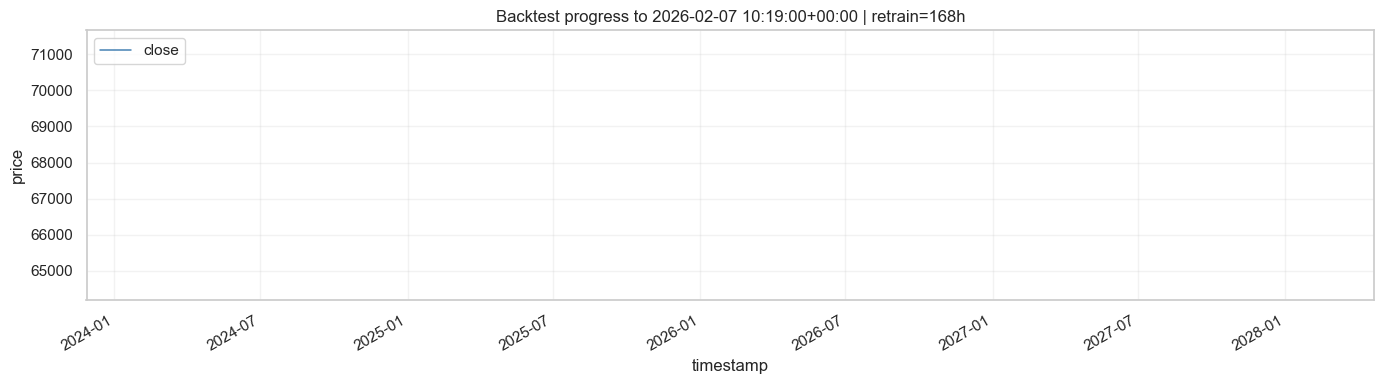

Trade action | ts=2026-02-07 10:20:00+00:00 | action=open_short | side=short | signal_type=trend_short | price=67949.2000 | qty=0.00367701 | realized_pnl=0.00 | free_cash=750.00 | invested_cash=250.00 | current_pnl=-0.15 | grid_pnl=-0.15 | equity=999.85 | reason=enter short: stable negative 10m/30m/60m bias
Trade action | ts=2026-02-07 11:38:00+00:00 | action=close_short | side=short | signal_type=trend_short | price=67826.7000 | qty=0.00367701 | realized_pnl=0.15 | free_cash=1000.30 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=0.15 | equity=1000.30 | reason=target_exit_price
Trade action | ts=2026-02-07 12:00:00+00:00 | action=open_short | side=short | signal_type=trend_short | price=68177.2000 | qty=0.00366582 | realized_pnl=0.00 | free_cash=750.23 | invested_cash=250.08 | current_pnl=-0.15 | grid_pnl=0.00 | equity=1000.15 | reason=enter short: stable negative 10m/30m/60m bias
Trade action | ts=2026-02-07 12:06:00+00:00 | action=close_short | side=short | signal_type=trend_shor

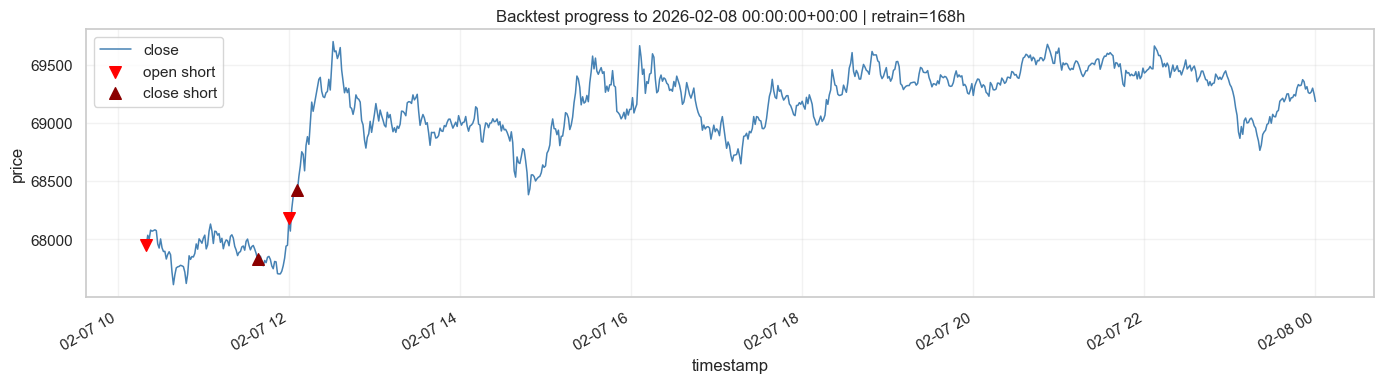

KeyboardInterrupt: 

In [68]:
from typing import Any

from IPython.display import display
import matplotlib.pyplot as plt

BACKTEST_ENABLED = True  # Включить/выключить backtest-блок
BACKTEST_START_DAYS_AGO = 30  # С какой точки в прошлом стартует тест: 30 = начинаем 30 дней назад от последней свечи
BACKTEST_DURATION_DAYS = 30  # Длина тестового окна в днях
BACKTEST_TRAIN_MINUTES = 40_000  # Сколько минут истории брать для обучения перед каждой точкой backtest
BACKTEST_RETRAIN_EVERY_HOURS = 168 #24  # Выбранный интервал переобучения модели в backtest, в часах
BACKTEST_FORCE_CPU = LIVE_FORCE_CPU  # Принудительно считать backtest на CPU, даже если CUDA доступна
BACKTEST_SAVE_TO_CSV = True  # Сохранять полный журнал сделок в CSV
BACKTEST_DISPLAY_MAX_TRADES = 100  # Сколько последних строк журнала сделок показывать в выводе
BACKTEST_EVAL_EVERY_MINUTES = 1  # Работаем на стандартных минутных свечах биржи

BACKTEST_INITIAL_CAPITAL = 1_000.0  # Виртуальный стартовый счёт в USDT
BACKTEST_ENTRY_FRACTION = 0.25  # Какая доля свободного кэша идёт в одну сделку
BACKTEST_ACCOUNT_MODE = 'long_short_margin'  # Разрешаем и long, и short в одном сценарии
BACKTEST_EXECUTION_FEE_PCT = float(LIVE_MAX_SIDE_FEE_PCT)  # Худшая комиссия на исполнение каждой сделки

BACKTEST_MIN_60M_MOVE_PCT = 0.03  # Минимальный модуль 60m-прогноза для входа
BACKTEST_COST_GATE_RATIO = 0.60  # Какая доля effective cost попадает в фильтр на вход
BACKTEST_LONG_ENTRY_SCORE_MIN = 0.42  # Более строгий порог для входа в long
BACKTEST_SHORT_ENTRY_SCORE_MIN = 0.42  # Более строгий порог для входа в short
BACKTEST_EXIT_SCORE_MAX = 0.08  # Если bias почти исчез, позицию пора закрывать
BACKTEST_REVERSAL_SCORE_MIN = 0.55  # Сильный разворот в противоположную сторону
BACKTEST_COOLDOWN_MINUTES = 20  # Пауза после обычного закрытия перед новым входом
BACKTEST_MIN_HOLD_MINUTES = 30  # Не выходим из позиции слишком рано, если нет стопа
BACKTEST_TARGET_EXIT_MIN_HOLD_MINUTES = 45  # До target даём позиции время раскрыться
BACKTEST_MAX_HOLD_MINUTES = 240  # Предохранитель от слишком долгого зависания позиции
BACKTEST_TARGET_MOVE_FLOOR_PCT = 0.18  # Минимальная цель по движению, чтобы не фиксироваться через 1-10 минут
BACKTEST_SHARP_DROP_5M_PCT = 0.18  # ОЧЕНЬ резкое падение для принудительного выхода из long
BACKTEST_SHARP_RISE_5M_PCT = 0.18  # ОЧЕНЬ резкий рост для принудительного выхода из short
BACKTEST_SHARP_DROP_10M_PCT = 0.28  # Подтверждение резкого падения на 10m для long-exit
BACKTEST_SHARP_RISE_10M_PCT = 0.28  # Подтверждение резкого роста на 10m для short-exit
BACKTEST_MAX_CONSECUTIVE_SAME_SIDE = 2  # Сколько подряд входов в одну сторону разрешено
BACKTEST_SIDE_IMBALANCE_LIMIT = 3  # Максимальный перекос количества открытий short против long (и наоборот)

if not BACKTEST_ENABLED:

    print('Backtest disabled (BACKTEST_ENABLED=False).')

else:

    history_df = cleaned_data[RUN_SYMBOL][['timestamp', 'close']].copy()

    history_df['timestamp'] = pd.to_datetime(history_df['timestamp'], errors='coerce', utc=True)

    history_df['close'] = pd.to_numeric(history_df['close'], errors='coerce')

    history_df = history_df.dropna(subset=['timestamp', 'close'])

    history_df = history_df[history_df['close'] > 0].copy()

    history_df = history_df.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)

    if len(history_df) <= BACKTEST_TRAIN_MINUTES + LIVE_FORECAST_HORIZON_MINUTES:

        raise RuntimeError(
            f'Недостаточно истории для backtest: {len(history_df)} rows, нужно больше чем '
            f'{BACKTEST_TRAIN_MINUTES + LIVE_FORECAST_HORIZON_MINUTES}.'
        )

    if int(BACKTEST_START_DAYS_AGO) <= 0:

        raise ValueError('BACKTEST_START_DAYS_AGO должен быть > 0.')

    if int(BACKTEST_DURATION_DAYS) <= 0:

        raise ValueError('BACKTEST_DURATION_DAYS должен быть > 0.')

    if int(BACKTEST_RETRAIN_EVERY_HOURS) <= 0:

        raise ValueError('BACKTEST_RETRAIN_EVERY_HOURS должен быть > 0.')

    if float(BACKTEST_INITIAL_CAPITAL) <= 0.0:

        raise ValueError('BACKTEST_INITIAL_CAPITAL должен быть > 0.')

    if not (0.0 < float(BACKTEST_ENTRY_FRACTION) <= 1.0):

        raise ValueError('BACKTEST_ENTRY_FRACTION должен быть в диапазоне (0, 1].')

    BACKTEST_STEP_MINUTES = max(1, int(BACKTEST_EVAL_EVERY_MINUTES))
    BACKTEST_EXECUTION_FEE_RATE = float(BACKTEST_EXECUTION_FEE_PCT / 100.0)

    def _bt_clip_score(value: float, scale: float) -> float:

        if not np.isfinite(value):

            return 0.0

        safe_scale = max(float(scale), 1e-6)

        return float(np.clip(float(value) / safe_scale, -1.5, 1.5))

    def _bt_forecast_catboost_path(model_obj: dict[str, Any], history_series: pd.Series, horizon: int) -> pd.DataFrame:

        history_arr = pd.to_numeric(history_series, errors='coerce').dropna().astype(float).to_numpy()

        if len(history_arr) < 10:

            raise RuntimeError('Недостаточно истории для backtest-прогноза.')

        context = int(model_obj['context'])

        ret_mean = float(model_obj['ret_mean'])

        ret_std = float(model_obj['ret_std'])

        model = model_obj['model']

        history_log = list(np.log(np.clip(history_arr, 1e-8, None)).astype(float))

        history_ret_norm = list(((np.diff(np.log(np.clip(history_arr, 1e-8, None))) - ret_mean) / ret_std).astype(float))

        rows = []

        for step_idx in range(int(horizon)):

            if len(history_ret_norm) >= context:

                x_ctx = np.asarray(history_ret_norm[-context:], dtype=np.float32)

            else:

                first_val = history_ret_norm[0] if len(history_ret_norm) > 0 else 0.0

                pad = np.full((context - len(history_ret_norm),), first_val, dtype=np.float32)

                x_ctx = np.concatenate([pad, np.asarray(history_ret_norm, dtype=np.float32)])

            pred_ret_norm = float(model.predict(x_ctx.reshape(1, -1))[0])

            pred_ret = pred_ret_norm * ret_std + ret_mean

            pred_ret = float(np.clip(pred_ret, -0.20, 0.20))

            pred_log = float(history_log[-1] + pred_ret)

            pred_price = float(np.exp(pred_log))

            rows.append({'step_minute': int(step_idx + 1), 'pred_price': pred_price})

            history_log.append(pred_log)

            history_ret_norm.append(pred_ret_norm)

        return pd.DataFrame(rows)

    def _bt_calc_move_pct(predicted_price: float, current_price: float) -> float:

        if not np.isfinite(predicted_price) or not np.isfinite(current_price) or float(current_price) == 0.0:

            return float('nan')

        return float((float(predicted_price) / float(current_price) - 1.0) * 100.0)

    def _bt_extract_horizon_forecasts(forecast_path_df: pd.DataFrame, current_price: float, horizons: list[int]) -> dict[str, float]:

        out: dict[str, float] = {}

        for horizon in horizons:

            horizon_idx = max(0, min(int(horizon) - 1, len(forecast_path_df) - 1))

            pred_price = float(forecast_path_df['pred_price'].iloc[horizon_idx])

            out[f'pred_{int(horizon)}m'] = pred_price

            out[f'move_{int(horizon)}m_pct'] = _bt_calc_move_pct(pred_price, current_price)

        return out

    def _bt_build_trade_signal(current_price: float, horizon_forecasts: dict[str, float]) -> dict[str, Any]:

        move_1m_pct = float(horizon_forecasts.get('move_1m_pct', float('nan')))
        move_5m_pct = float(horizon_forecasts.get('move_5m_pct', float('nan')))
        move_10m_pct = float(horizon_forecasts.get('move_10m_pct', float('nan')))
        move_15m_pct = float(horizon_forecasts.get('move_15m_pct', float('nan')))
        move_30m_pct = float(horizon_forecasts.get('move_30m_pct', float('nan')))
        move_60m_pct = float(horizon_forecasts.get('move_60m_pct', float('nan')))

        thresholds = _compute_signal_thresholds(horizon_forecasts)
        forecast_scale_pct = float(thresholds['forecast_scale_pct'])
        required_move_pct = float(thresholds['required_move_pct'])
        effective_cost_pct = float(thresholds['effective_cost_pct'])
        entry_trigger_move_pct = float(thresholds['entry_trigger_move_pct'])
        adaptive_pullback_pct = float(thresholds['adaptive_pullback_pct'])
        adaptive_reversal_pct = float(thresholds['adaptive_reversal_pct'])

        long_edge_pct = float(move_60m_pct - effective_cost_pct)
        short_edge_pct = float((-move_60m_pct) - effective_cost_pct)

        scale_5m = float(max(required_move_pct * 0.25, LIVE_CONFIRM_1M_PCT, 0.01))
        scale_10m = float(max(required_move_pct * 0.35, LIVE_CONFIRM_1M_PCT, 0.01))
        scale_30m = float(max(required_move_pct * 0.60, LIVE_CONFIRM_1M_PCT, 0.01))
        scale_60m = float(max(required_move_pct, LIVE_ENTRY_MIN_MOVE_PCT, 0.01))

        score_5m = _bt_clip_score(move_5m_pct, scale_5m)
        score_10m = _bt_clip_score(move_10m_pct, scale_10m)
        score_30m = _bt_clip_score(move_30m_pct, scale_30m)
        score_60m = _bt_clip_score(move_60m_pct, scale_60m)

        long_bias_score = float(0.10 * score_5m + 0.20 * score_10m + 0.30 * score_30m + 0.40 * score_60m)
        short_bias_score = float(0.10 * max(-score_5m, 0.0) + 0.20 * max(-score_10m, 0.0) + 0.30 * max(-score_30m, 0.0) + 0.40 * max(-score_60m, 0.0))
        long_entry_score = float(0.10 * max(score_5m, 0.0) + 0.20 * max(score_10m, 0.0) + 0.30 * max(score_30m, 0.0) + 0.40 * max(score_60m, 0.0))
        short_entry_score = float(0.10 * max(-score_5m, 0.0) + 0.20 * max(-score_10m, 0.0) + 0.30 * max(-score_30m, 0.0) + 0.40 * max(-score_60m, 0.0))

        min_entry_move_pct = float(max(BACKTEST_MIN_60M_MOVE_PCT, effective_cost_pct * BACKTEST_COST_GATE_RATIO))
        entry_side = 'flat'
        entry_reason = 'wait: no stable directional bias yet'
        signal = 'hold'
        signal_type = 'none'
        target_exit_price = float('nan')
        reason = f'adaptive edge below threshold: |move_60m| < {entry_trigger_move_pct:.3f}%'

        trend_long = False
        trend_short = False
        dip_long = False
        rally_short = False

        if all(np.isfinite(v) for v in [move_1m_pct, move_5m_pct, move_10m_pct, move_30m_pct, move_60m_pct]):

            trend_long = (
                move_60m_pct >= entry_trigger_move_pct
                and long_edge_pct >= 0.0
                and move_10m_pct >= LIVE_CONFIRM_1M_PCT
                and move_30m_pct > 0.0
            )
            trend_short = (
                (-move_60m_pct) >= entry_trigger_move_pct
                and short_edge_pct >= 0.0
                and move_10m_pct <= -LIVE_CONFIRM_1M_PCT
                and move_30m_pct < 0.0
            )
            dip_long = (
                move_60m_pct >= entry_trigger_move_pct
                and long_edge_pct >= 0.0
                and move_5m_pct <= -adaptive_pullback_pct
                and move_10m_pct >= adaptive_reversal_pct
                and move_30m_pct > 0.0
            )
            rally_short = (
                (-move_60m_pct) >= entry_trigger_move_pct
                and short_edge_pct >= 0.0
                and move_5m_pct >= adaptive_pullback_pct
                and move_10m_pct <= -adaptive_reversal_pct
                and move_30m_pct < 0.0
            )

            if dip_long:
                signal = 'long'
                signal_type = 'buy_dip'
                reason = 'adaptive buy_dip: short pullback with recovery on 10m/30m/60m'
            elif rally_short:
                signal = 'short'
                signal_type = 'sell_rally'
                reason = 'adaptive sell_rally: short rally with decline on 10m/30m/60m'
            elif trend_long:
                signal = 'long'
                signal_type = 'trend_long'
                reason = 'adaptive trend_long: 10m/30m/60m aligned upward'
            elif trend_short:
                signal = 'short'
                signal_type = 'trend_short'
                reason = 'adaptive trend_short: 10m/30m/60m aligned downward'
            else:
                reason = 'adaptive threshold passed partly, but path is not aligned for entry' if max(abs(move_60m_pct), 0.0) >= entry_trigger_move_pct else reason

            if (
                move_60m_pct >= min_entry_move_pct
                and long_bias_score >= BACKTEST_LONG_ENTRY_SCORE_MIN
                and long_entry_score >= BACKTEST_LONG_ENTRY_SCORE_MIN
                and move_30m_pct >= -LIVE_CONFIRM_1M_PCT
            ):
                entry_side = 'long'
                entry_reason = 'enter long: stable positive 10m/30m/60m bias'
            elif (
                (-move_60m_pct) >= min_entry_move_pct
                and short_bias_score >= BACKTEST_SHORT_ENTRY_SCORE_MIN
                and short_entry_score >= BACKTEST_SHORT_ENTRY_SCORE_MIN
                and move_30m_pct <= LIVE_CONFIRM_1M_PCT
            ):
                entry_side = 'short'
                entry_reason = 'enter short: stable negative 10m/30m/60m bias'

        long_open_trigger = bool(entry_side == 'long')
        short_open_trigger = bool(entry_side == 'short')

        long_close_sharp_trigger = bool(
            (move_5m_pct <= -BACKTEST_SHARP_DROP_5M_PCT and move_10m_pct <= -BACKTEST_SHARP_DROP_10M_PCT)
            or (short_bias_score >= BACKTEST_REVERSAL_SCORE_MIN and move_10m_pct < 0.0)
        )
        short_close_sharp_trigger = bool(
            (move_5m_pct >= BACKTEST_SHARP_RISE_5M_PCT and move_10m_pct >= BACKTEST_SHARP_RISE_10M_PCT)
            or (long_bias_score >= BACKTEST_REVERSAL_SCORE_MIN and move_10m_pct > 0.0)
        )

        long_exit_trigger = bool(
            (long_bias_score <= BACKTEST_EXIT_SCORE_MAX and move_10m_pct <= 0.0 and move_30m_pct <= 0.0)
            or long_close_sharp_trigger
        )
        short_exit_trigger = bool(
            (short_bias_score <= BACKTEST_EXIT_SCORE_MAX and move_10m_pct >= 0.0 and move_30m_pct >= 0.0)
            or short_close_sharp_trigger
        )

        if entry_side == 'long':
            target_move_pct = float(max(BACKTEST_TARGET_MOVE_FLOOR_PCT, required_move_pct + effective_cost_pct, abs(move_60m_pct) * 0.85))
            target_exit_price = float(current_price * (1.0 + target_move_pct / 100.0))
        elif entry_side == 'short':
            target_move_pct = float(max(BACKTEST_TARGET_MOVE_FLOOR_PCT, required_move_pct + effective_cost_pct, abs(move_60m_pct) * 0.85))
            target_exit_price = float(current_price * (1.0 - target_move_pct / 100.0))

        return {
            'signal': signal,
            'signal_type': signal_type,
            'entry_side': entry_side,
            'entry_reason': entry_reason,
            'reason': reason,
            'move_1m_pct': move_1m_pct,
            'move_5m_pct': move_5m_pct,
            'move_10m_pct': move_10m_pct,
            'move_15m_pct': move_15m_pct,
            'move_30m_pct': move_30m_pct,
            'move_60m_pct': move_60m_pct,
            'forecast_scale_pct': forecast_scale_pct,
            'required_move_pct': required_move_pct,
            'effective_cost_pct': effective_cost_pct,
            'entry_trigger_move_pct': entry_trigger_move_pct,
            'adaptive_pullback_pct': adaptive_pullback_pct,
            'adaptive_reversal_pct': adaptive_reversal_pct,
            'long_edge_pct': long_edge_pct,
            'short_edge_pct': short_edge_pct,
            'long_bias_score': long_bias_score,
            'short_bias_score': short_bias_score,
            'long_entry_score': long_entry_score,
            'short_entry_score': short_entry_score,
            'min_entry_move_pct': min_entry_move_pct,
            'long_open_trigger': long_open_trigger,
            'short_open_trigger': short_open_trigger,
            'long_close_sharp_trigger': long_close_sharp_trigger,
            'short_close_sharp_trigger': short_close_sharp_trigger,
            'long_exit_trigger': long_exit_trigger,
            'short_exit_trigger': short_exit_trigger,
            'target_exit_price': target_exit_price,
        }

    def _bt_position_levels(side: str, avg_entry_price: float) -> tuple[float, float]:

        if side == 'long':
            return (
                float(avg_entry_price * (1.0 - LIVE_STOP_LOSS_PCT / 100.0)),
                float(avg_entry_price * (1.0 + LIVE_TAKE_PROFIT_PCT / 100.0)),
            )
        return (
            float(avg_entry_price * (1.0 + LIVE_STOP_LOSS_PCT / 100.0)),
            float(avg_entry_price * (1.0 - LIVE_TAKE_PROFIT_PCT / 100.0)),
        )

    def _bt_position_price_pnl(position: dict[str, Any] | None, current_price: float) -> float:

        if position is None:
            return 0.0

        qty = float(position['qty'])
        avg_entry = float(position['avg_entry_price'])
        if position['side'] == 'long':
            return float((current_price - avg_entry) * qty)
        return float((avg_entry - current_price) * qty)

    def _bt_position_unrealized_pnl(position: dict[str, Any] | None, current_price: float) -> float:

        if position is None:
            return 0.0

        exit_notional = float(position['qty'] * current_price)
        exit_fee = float(exit_notional * BACKTEST_EXECUTION_FEE_RATE)
        return float(_bt_position_price_pnl(position, current_price) - exit_fee)

    def _bt_open_position(side: str, signal_type: str, current_price: float, current_ts: pd.Timestamp, target_exit_price: float, free_cash: float, fraction: float) -> dict[str, Any] | None:

        allocation_cash = float(min(free_cash, max(0.0, free_cash * float(fraction))))

        if allocation_cash <= 0.0 or current_price <= 0.0:
            return None

        entry_fee_cash = float(allocation_cash * BACKTEST_EXECUTION_FEE_RATE)
        exposure_cash = float(allocation_cash - entry_fee_cash)

        if exposure_cash <= 0.0:
            return None

        qty = float(exposure_cash / current_price)
        stop_loss, take_profit = _bt_position_levels(side, current_price)

        return {
            'side': side,
            'signal_type': signal_type,
            'opened_at': current_ts,
            'min_hold_until': current_ts + pd.Timedelta(minutes=BACKTEST_MIN_HOLD_MINUTES),
            'target_exit_eligible_at': current_ts + pd.Timedelta(minutes=BACKTEST_TARGET_EXIT_MIN_HOLD_MINUTES),
            'force_exit_at': current_ts + pd.Timedelta(minutes=BACKTEST_MAX_HOLD_MINUTES),
            'avg_entry_price': float(current_price),
            'qty': qty,
            'asset_qty': qty,
            'invested_cash_gross': allocation_cash,
            'entry_fee_cash': entry_fee_cash,
            'target_exit_price': float(target_exit_price),
            'stop_loss': float(stop_loss),
            'take_profit': float(take_profit),
        }

    def _bt_close_position(position: dict[str, Any], current_price: float, current_ts: pd.Timestamp, reason: str) -> tuple[float, dict[str, Any]]:

        exit_notional = float(position['qty'] * current_price)
        exit_fee_cash = float(exit_notional * BACKTEST_EXECUTION_FEE_RATE)
        price_pnl = float(_bt_position_price_pnl(position, current_price))
        released_cash = float(position['invested_cash_gross'] + price_pnl - exit_fee_cash)
        realized_pnl = float(price_pnl - float(position['entry_fee_cash']) - exit_fee_cash)

        trade = {
            'side': position['side'],
            'signal_type': position['signal_type'],
            'opened_at': position['opened_at'],
            'closed_at': current_ts,
            'avg_entry_price': float(position['avg_entry_price']),
            'exit_price': float(current_price),
            'target_exit_price': float(position['target_exit_price']),
            'qty': float(position['qty']),
            'asset_qty': float(position['qty']),
            'entry_fee_cash': float(position['entry_fee_cash']),
            'exit_fee_cash': float(exit_fee_cash),
            'invested_cash_gross': float(position['invested_cash_gross']),
            'gross_sale_value': float(exit_notional),
            'net_sale_value': float(released_cash),
            'realized_pnl': realized_pnl,
            'return_pct': float(realized_pnl / float(position['invested_cash_gross']) * 100.0) if float(position['invested_cash_gross']) > 0 else float('nan'),
            'close_reason': reason,
        }

        return released_cash, trade

    def _bt_print_trade_action(action_row: dict[str, Any], free_cash: float, position: dict[str, Any] | None, realized_pnl_total: float, current_price: float) -> None:

        invested_cash_now = float(position['invested_cash_gross']) if position is not None else 0.0
        current_pnl_now = float(_bt_position_unrealized_pnl(position, current_price)) if position is not None else 0.0
        grid_pnl_now = float(realized_pnl_total + current_pnl_now)
        equity_now = float(free_cash + invested_cash_now + current_pnl_now)
        realized_pnl_value = float(action_row['realized_pnl']) if np.isfinite(action_row.get('realized_pnl', np.nan)) else 0.0

        print(
            f'Trade action | ts={pd.Timestamp(action_row["timestamp"])} | action={action_row["action"]} | '
            f'side={action_row["side"]} | signal_type={action_row["signal_type"]} | price={float(action_row["price"]):.4f} | '
            f'qty={float(action_row["qty"]):.8f} | realized_pnl={realized_pnl_value:.2f} | '
            f'free_cash={free_cash:.2f} | invested_cash={invested_cash_now:.2f} | '
            f'current_pnl={current_pnl_now:.2f} | grid_pnl={grid_pnl_now:.2f} | '
            f'equity={equity_now:.2f} | reason={action_row["reason"]}'
        )

    def _bt_plot_progress_chart(history_slice_df: pd.DataFrame, trades_df: pd.DataFrame, current_ts: pd.Timestamp, retrain_hours: int) -> None:

        if len(history_slice_df) == 0:
            return

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(
            history_slice_df['timestamp'],
            history_slice_df['close'],
            color='steelblue',
            linewidth=1.1,
            label='close',
        )

        if len(trades_df) > 0:
            trades_view_df = trades_df.copy()
            trades_view_df['timestamp'] = pd.to_datetime(trades_view_df['timestamp'], utc=True)
            trades_view_df = trades_view_df.loc[trades_view_df['timestamp'] <= current_ts].copy()

            for action_name, color, marker, label in [
                ('open_long', 'green', '^', 'open long'),
                ('close_long', 'darkgreen', 'v', 'close long'),
                ('open_short', 'red', 'v', 'open short'),
                ('close_short', 'darkred', '^', 'close short'),
            ]:
                action_df = trades_view_df.loc[trades_view_df['action'] == action_name].copy()
                if len(action_df) > 0:
                    ax.scatter(
                        action_df['timestamp'],
                        action_df['price'],
                        color=color,
                        marker=marker,
                        s=70,
                        label=label,
                        zorder=3,
                    )

        ax.set_title(f'Backtest progress to {current_ts} | retrain={retrain_hours}h')
        ax.set_xlabel('timestamp')
        ax.set_ylabel('price')
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper left')
        fig.autofmt_xdate()
        plt.tight_layout()
        display(fig)
        plt.close(fig)

    def _run_backtest_scenario(retrain_hours: int) -> tuple[pd.DataFrame, dict[str, Any]]:

        retrain_minutes = int(retrain_hours * 60)
        end_available_ts = pd.Timestamp(history_df['timestamp'].iloc[-1]).floor('min')
        requested_start_ts = end_available_ts - pd.Timedelta(days=float(BACKTEST_START_DAYS_AGO))
        requested_end_ts = requested_start_ts + pd.Timedelta(days=float(BACKTEST_DURATION_DAYS))
        target_end_ts = min(end_available_ts, requested_end_ts)

        start_candidates = history_df.index[history_df['timestamp'] >= requested_start_ts]
        end_candidates = history_df.index[history_df['timestamp'] <= target_end_ts]

        if len(start_candidates) == 0 or len(end_candidates) == 0:
            raise RuntimeError('Не удалось найти диапазон backtest в истории.')

        start_idx = int(start_candidates[0])
        end_idx = int(end_candidates[-1])
        actual_start_ts = pd.Timestamp(history_df['timestamp'].iloc[start_idx]).floor('min')
        actual_end_ts = pd.Timestamp(history_df['timestamp'].iloc[end_idx]).floor('min')

        if start_idx < int(BACKTEST_TRAIN_MINUTES):
            raise RuntimeError(
                f'Слишком ранний старт backtest: до него только {start_idx} строк истории, нужно минимум {BACKTEST_TRAIN_MINUTES}.'
            )

        if end_idx <= start_idx:
            raise RuntimeError('Диапазон backtest пустой или некорректный.')

        bt_state = {
            'free_cash': float(BACKTEST_INITIAL_CAPITAL),
            'realized_pnl': 0.0,
            'position': None,
            'last_exit_ts': None,
            'last_open_side': None,
            'same_side_open_streak': 0,
            'open_long_count': 0,
            'open_short_count': 0,
        }

        bt_trades = []
        bt_active_model = None
        total_steps = len(range(start_idx, end_idx + 1, int(BACKTEST_STEP_MINUTES)))
        processed_steps = 0
        last_report_day = None

        print(
            f'Scenario start | mode={BACKTEST_ACCOUNT_MODE} | capital={BACKTEST_INITIAL_CAPITAL:.2f} | '
            f'entry_fraction={BACKTEST_ENTRY_FRACTION:.2f} | fee_pct={BACKTEST_EXECUTION_FEE_PCT:.4f} | '
            f'retrain_every={retrain_hours}h | from={actual_start_ts} | to={actual_end_ts} | steps={total_steps}'
        )

        for idx in range(start_idx, end_idx + 1, int(BACKTEST_STEP_MINUTES)):

            row = history_df.iloc[idx]
            current_ts = pd.Timestamp(row['timestamp']).floor('min')
            current_price = float(row['close'])

            train_window = history_df.iloc[idx - int(BACKTEST_TRAIN_MINUTES) + 1:idx + 1].reset_index(drop=True)
            train_series = train_window['close'].astype(float).reset_index(drop=True)

            needs_refit = bt_active_model is None or current_ts >= bt_active_model['expires_at']

            if needs_refit:
                model_obj = fit_catboost_inference_model(
                    train_series,
                    context_len=int(catboost_best_params['context_len']),
                    depth=int(catboost_best_params['depth']),
                    learning_rate=float(catboost_best_params['learning_rate']),
                    iterations=int(catboost_best_params['iterations']),
                    l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
                    use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)) and not BACKTEST_FORCE_CPU,
                )
                bt_active_model = {
                    'model_obj': model_obj,
                    'fitted_at': current_ts,
                    'expires_at': current_ts + pd.Timedelta(minutes=retrain_minutes),
                }
                print(
                    f'Retrained model | ts={current_ts} | retrain_every={retrain_hours}h | '
                    f'trade_actions={len(bt_trades)}'
                )

            forecast_path_df = _bt_forecast_catboost_path(
                bt_active_model['model_obj'],
                history_series=train_series,
                horizon=int(LIVE_FORECAST_HORIZON_MINUTES),
            )

            horizon_forecasts = _bt_extract_horizon_forecasts(
                forecast_path_df=forecast_path_df,
                current_price=current_price,
                horizons=[int(h) for h in LIVE_SIGNAL_HORIZONS],
            )

            trade_signal = _bt_build_trade_signal(
                current_price=current_price,
                horizon_forecasts=horizon_forecasts,
            )

            position = bt_state['position']
            close_reason = None
            exit_was_flip = False

            if position is not None:
                in_min_hold = current_ts < pd.Timestamp(position['min_hold_until'])
                target_allowed = current_ts >= pd.Timestamp(position['target_exit_eligible_at'])
                force_exit = current_ts >= pd.Timestamp(position['force_exit_at'])

                if position['side'] == 'long':
                    if current_price <= float(position['stop_loss']):
                        close_reason = 'stop_loss'
                    elif current_price >= float(position['take_profit']):
                        close_reason = 'take_profit'
                    elif target_allowed and np.isfinite(position['target_exit_price']) and current_price >= float(position['target_exit_price']):
                        close_reason = 'target_exit_price'
                    elif force_exit:
                        close_reason = 'max_hold_reached'
                    elif trade_signal['long_close_sharp_trigger']:
                        close_reason = 'sharp_drop_close_long'
                    elif not in_min_hold and trade_signal['long_exit_trigger']:
                        close_reason = 'signal_exit_long'
                    elif not in_min_hold and trade_signal['entry_side'] == 'short' and trade_signal['short_bias_score'] >= BACKTEST_REVERSAL_SCORE_MIN:
                        close_reason = 'signal_flip_to_short'
                        exit_was_flip = True
                else:
                    if current_price >= float(position['stop_loss']):
                        close_reason = 'stop_loss'
                    elif current_price <= float(position['take_profit']):
                        close_reason = 'take_profit'
                    elif target_allowed and np.isfinite(position['target_exit_price']) and current_price <= float(position['target_exit_price']):
                        close_reason = 'target_exit_price'
                    elif force_exit:
                        close_reason = 'max_hold_reached'
                    elif trade_signal['short_close_sharp_trigger']:
                        close_reason = 'sharp_rise_close_short'
                    elif not in_min_hold and trade_signal['short_exit_trigger']:
                        close_reason = 'signal_exit_short'
                    elif not in_min_hold and trade_signal['entry_side'] == 'long' and trade_signal['long_bias_score'] >= BACKTEST_REVERSAL_SCORE_MIN:
                        close_reason = 'signal_flip_to_long'
                        exit_was_flip = True

                if close_reason is not None:
                    released_cash, closed_trade = _bt_close_position(position, current_price, current_ts, close_reason)
                    bt_state['free_cash'] = float(bt_state['free_cash'] + released_cash)
                    bt_state['realized_pnl'] = float(bt_state['realized_pnl'] + closed_trade['realized_pnl'])

                    trade_action_row = {
                        'retrain_hours': int(retrain_hours),
                        'timestamp': current_ts,
                        'action': f'close_{position["side"]}',
                        'side': position['side'],
                        'signal_type': position['signal_type'],
                        'price': float(current_price),
                        'qty': float(position['qty']),
                        'asset_qty': float(position['qty']),
                        'cash_flow': float(released_cash),
                        'invested_cash_gross': float(position['invested_cash_gross']),
                        'entry_fee_cash': float(position['entry_fee_cash']),
                        'exit_fee_cash': float(closed_trade['exit_fee_cash']),
                        'gross_sale_value': float(closed_trade['gross_sale_value']),
                        'net_sale_value': float(closed_trade['net_sale_value']),
                        'realized_pnl': float(closed_trade['realized_pnl']),
                        'position_qty_after': 0.0,
                        'avg_entry_after': float('nan'),
                        'free_cash_after': float(bt_state['free_cash']),
                        'equity_after': float(bt_state['free_cash']),
                        'reason': close_reason,
                    }

                    bt_trades.append(trade_action_row)
                    bt_state['position'] = None
                    bt_state['last_exit_ts'] = None if exit_was_flip else current_ts

                    _bt_print_trade_action(
                        trade_action_row,
                        free_cash=float(bt_state['free_cash']),
                        position=None,
                        realized_pnl_total=float(bt_state['realized_pnl']),
                        current_price=current_price,
                    )

            cooldown_ready = bt_state['last_exit_ts'] is None or current_ts >= pd.Timestamp(bt_state['last_exit_ts']) + pd.Timedelta(minutes=BACKTEST_COOLDOWN_MINUTES)

            if bt_state['position'] is None and cooldown_ready and (trade_signal['long_open_trigger'] or trade_signal['short_open_trigger']):
                entry_side = str(trade_signal['entry_side'])
                open_long_count = int(bt_state['open_long_count'])
                open_short_count = int(bt_state['open_short_count'])
                side_imbalance = int(open_short_count - open_long_count)
                same_side_streak = int(bt_state['same_side_open_streak']) if bt_state['last_open_side'] == entry_side else 0

                side_balance_allowed = True
                side_balance_reason = ''

                if same_side_streak >= int(BACKTEST_MAX_CONSECUTIVE_SAME_SIDE):
                    side_balance_allowed = False
                    side_balance_reason = f'blocked by same-side streak: {entry_side}'

                if side_balance_allowed and entry_side == 'short' and side_imbalance >= int(BACKTEST_SIDE_IMBALANCE_LIMIT):
                    side_balance_allowed = False
                    side_balance_reason = f'blocked by side imbalance: shorts={open_short_count}, longs={open_long_count}'

                if side_balance_allowed and entry_side == 'long' and side_imbalance <= -int(BACKTEST_SIDE_IMBALANCE_LIMIT):
                    side_balance_allowed = False
                    side_balance_reason = f'blocked by side imbalance: shorts={open_short_count}, longs={open_long_count}'

                if not side_balance_allowed:
                    entry_side = 'flat'
                    trade_signal['entry_reason'] = side_balance_reason

                if entry_side in {'long', 'short'}:
                    default_signal_type = 'trend_long' if entry_side == 'long' else 'trend_short'
                    new_position = _bt_open_position(
                        side=entry_side,
                        signal_type=trade_signal['signal_type'] if trade_signal['signal_type'] != 'none' else default_signal_type,
                        current_price=current_price,
                        current_ts=current_ts,
                        target_exit_price=float(trade_signal['target_exit_price']),
                        free_cash=float(bt_state['free_cash']),
                        fraction=float(BACKTEST_ENTRY_FRACTION),
                    )
                else:
                    new_position = None

                if new_position is not None:
                    bt_state['free_cash'] = float(bt_state['free_cash'] - new_position['invested_cash_gross'])
                    bt_state['position'] = new_position
                    if bt_state['last_open_side'] == entry_side:
                        bt_state['same_side_open_streak'] = int(bt_state['same_side_open_streak']) + 1
                    else:
                        bt_state['same_side_open_streak'] = 1
                    bt_state['last_open_side'] = entry_side
                    if entry_side == 'long':
                        bt_state['open_long_count'] = int(bt_state['open_long_count']) + 1
                    else:
                        bt_state['open_short_count'] = int(bt_state['open_short_count']) + 1
                    equity_after = float(bt_state['free_cash'] + new_position['invested_cash_gross'] + _bt_position_unrealized_pnl(new_position, current_price))

                    trade_action_row = {
                        'retrain_hours': int(retrain_hours),
                        'timestamp': current_ts,
                        'action': f'open_{entry_side}',
                        'side': entry_side,
                        'signal_type': new_position['signal_type'],
                        'price': float(current_price),
                        'qty': float(new_position['qty']),
                        'asset_qty': float(new_position['qty']),
                        'cash_flow': float(-new_position['invested_cash_gross']),
                        'invested_cash_gross': float(new_position['invested_cash_gross']),
                        'entry_fee_cash': float(new_position['entry_fee_cash']),
                        'exit_fee_cash': float('nan'),
                        'gross_sale_value': float('nan'),
                        'net_sale_value': float('nan'),
                        'realized_pnl': float('nan'),
                        'position_qty_after': float(new_position['qty']),
                        'avg_entry_after': float(new_position['avg_entry_price']),
                        'free_cash_after': float(bt_state['free_cash']),
                        'equity_after': equity_after,
                        'reason': trade_signal['entry_reason'],
                    }

                    bt_trades.append(trade_action_row)

                    _bt_print_trade_action(
                        trade_action_row,
                        free_cash=float(bt_state['free_cash']),
                        position=bt_state['position'],
                        realized_pnl_total=float(bt_state['realized_pnl']),
                        current_price=current_price,
                    )

            processed_steps += 1
            current_day = current_ts.normalize()
            invested_cash_now = float(bt_state['position']['invested_cash_gross']) if bt_state['position'] is not None else 0.0
            current_pnl_now = float(_bt_position_unrealized_pnl(bt_state['position'], current_price)) if bt_state['position'] is not None else 0.0
            grid_pnl_now = float(bt_state['realized_pnl'] + current_pnl_now)
            equity_now = float(bt_state['free_cash'] + invested_cash_now + current_pnl_now)

            if last_report_day is None or current_day > last_report_day:
                last_report_day = current_day
                print(
                    f'Progress | date={current_day.date()} | '
                    f'step={processed_steps}/{total_steps} | trade_actions={len(bt_trades)} | '
                    f'free_cash={bt_state["free_cash"]:.2f} | invested_cash={invested_cash_now:.2f} | '
                    f'current_pnl={current_pnl_now:.2f} | grid_pnl={grid_pnl_now:.2f} | equity={equity_now:.2f}'
                )
                _bt_plot_progress_chart(
                    history_slice_df=history_df.iloc[start_idx:idx + 1][['timestamp', 'close']].copy(),
                    trades_df=pd.DataFrame(bt_trades),
                    current_ts=current_ts,
                    retrain_hours=int(retrain_hours),
                )

        if bt_state['position'] is not None:
            last_row = history_df.iloc[end_idx]
            final_ts = pd.Timestamp(last_row['timestamp']).floor('min')
            final_price = float(last_row['close'])
            position = bt_state['position']

            released_cash, closed_trade = _bt_close_position(position, final_price, final_ts, 'backtest_end')
            bt_state['free_cash'] = float(bt_state['free_cash'] + released_cash)
            bt_state['realized_pnl'] = float(bt_state['realized_pnl'] + closed_trade['realized_pnl'])

            trade_action_row = {
                'retrain_hours': int(retrain_hours),
                'timestamp': final_ts,
                'action': f'close_{position["side"]}',
                'side': position['side'],
                'signal_type': position['signal_type'],
                'price': float(final_price),
                'qty': float(position['qty']),
                'asset_qty': float(position['qty']),
                'cash_flow': float(released_cash),
                'invested_cash_gross': float(position['invested_cash_gross']),
                'entry_fee_cash': float(position['entry_fee_cash']),
                'exit_fee_cash': float(closed_trade['exit_fee_cash']),
                'gross_sale_value': float(closed_trade['gross_sale_value']),
                'net_sale_value': float(closed_trade['net_sale_value']),
                'realized_pnl': float(closed_trade['realized_pnl']),
                'position_qty_after': 0.0,
                'avg_entry_after': float('nan'),
                'free_cash_after': float(bt_state['free_cash']),
                'equity_after': float(bt_state['free_cash']),
                'reason': 'backtest_end',
            }

            bt_trades.append(trade_action_row)
            bt_state['position'] = None
            bt_state['last_exit_ts'] = final_ts

            _bt_print_trade_action(
                trade_action_row,
                free_cash=float(bt_state['free_cash']),
                position=None,
                realized_pnl_total=float(bt_state['realized_pnl']),
                current_price=final_price,
            )

        trades_df = pd.DataFrame(bt_trades)

        if len(trades_df) == 0:
            trades_df = pd.DataFrame(columns=[
                'retrain_hours', 'timestamp', 'action', 'side', 'signal_type', 'price', 'qty', 'asset_qty', 'cash_flow',
                'invested_cash_gross', 'entry_fee_cash', 'exit_fee_cash', 'gross_sale_value', 'net_sale_value',
                'realized_pnl', 'position_qty_after', 'avg_entry_after', 'free_cash_after', 'equity_after', 'reason'
            ])

        close_trades_df = trades_df[trades_df['action'].astype(str).str.startswith('close_')].copy() if len(trades_df) > 0 else pd.DataFrame()

        scenario_meta = {
            'retrain_hours': int(retrain_hours),
            'requested_start_ts': requested_start_ts,
            'requested_end_ts': requested_end_ts,
            'actual_start_ts': actual_start_ts,
            'actual_end_ts': actual_end_ts,
            'effective_duration_days': float((actual_end_ts - actual_start_ts).total_seconds() / 86_400.0),
            'eval_step_minutes': int(BACKTEST_STEP_MINUTES),
            'account_mode': BACKTEST_ACCOUNT_MODE,
            'initial_capital': float(BACKTEST_INITIAL_CAPITAL),
            'entry_fraction': float(BACKTEST_ENTRY_FRACTION),
            'execution_fee_pct': float(BACKTEST_EXECUTION_FEE_PCT),
            'trade_actions': int(len(trades_df)),
            'closed_trades': int(len(close_trades_df)),
            'opened_longs': int(bt_state['open_long_count']),
            'opened_shorts': int(bt_state['open_short_count']),
            'ending_equity': float(bt_state['free_cash']),
            'ending_realized_pnl': float(bt_state['realized_pnl']),
        }

        return trades_df, scenario_meta

    backtest_results = []
    backtest_meta_rows = []

    print(f'Backtest symbol={RUN_SYMBOL} | start_days_ago={BACKTEST_START_DAYS_AGO} | duration_days={BACKTEST_DURATION_DAYS}')
    print(
        f'Train minutes={BACKTEST_TRAIN_MINUTES} | retrain_every_hours={BACKTEST_RETRAIN_EVERY_HOURS} | '
        f'eval_step_minutes={BACKTEST_STEP_MINUTES}'
    )
    print(
        f'Account mode={BACKTEST_ACCOUNT_MODE} | initial_capital={BACKTEST_INITIAL_CAPITAL:.2f} | '
        f'entry_fraction={BACKTEST_ENTRY_FRACTION:.2f} | execution_fee_pct={BACKTEST_EXECUTION_FEE_PCT:.4f}'
    )

    if int(BACKTEST_DURATION_DAYS) > int(BACKTEST_START_DAYS_AGO):
        print(
            'Note: duration_days > start_days_ago, поэтому конец окна будет обрезан последней доступной точкой истории. '
            'Для полного окна обычно ставь start_days_ago >= duration_days.'
        )

    for retrain_hours in [int(BACKTEST_RETRAIN_EVERY_HOURS)]:
        scenario_trades_df, scenario_meta = _run_backtest_scenario(int(retrain_hours))
        backtest_results.append(scenario_trades_df)
        backtest_meta_rows.append(scenario_meta)

    BACKTEST_TRADES_DF = pd.concat(backtest_results, ignore_index=True) if len(backtest_results) > 0 else pd.DataFrame()
    BACKTEST_META_DF = pd.DataFrame(backtest_meta_rows).sort_values('retrain_hours').reset_index(drop=True)

    BACKTEST_TRADES_PATH = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_backtest_trades_{pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')}.csv"

    if BACKTEST_SAVE_TO_CSV and len(BACKTEST_TRADES_DF) > 0:
        BACKTEST_TRADES_DF.to_csv(BACKTEST_TRADES_PATH, index=False)

    BACKTEST_TRADES_VIEW_DF = BACKTEST_TRADES_DF[[
        'retrain_hours', 'timestamp', 'action', 'side', 'signal_type', 'price', 'qty', 'cash_flow', 'realized_pnl', 'free_cash_after', 'equity_after', 'reason'
    ]].copy() if len(BACKTEST_TRADES_DF) > 0 else pd.DataFrame()

    daily_activity_rows = []

    for _, meta_row in BACKTEST_META_DF.iterrows():
        retrain_hours = int(meta_row['retrain_hours'])
        day_range = pd.date_range(
            pd.Timestamp(meta_row['actual_start_ts']).normalize(),
            pd.Timestamp(meta_row['actual_end_ts']).normalize(),
            freq='D',
            tz='UTC',
        )

        scenario_trades_df = BACKTEST_TRADES_DF.loc[BACKTEST_TRADES_DF['retrain_hours'] == retrain_hours].copy() if len(BACKTEST_TRADES_DF) > 0 else pd.DataFrame()

        if len(scenario_trades_df) > 0:
            scenario_trades_df['trade_day'] = pd.to_datetime(scenario_trades_df['timestamp'], utc=True).dt.normalize()
            day_counts = scenario_trades_df.groupby('trade_day').size().to_dict()
        else:
            day_counts = {}

        for day_ts in day_range:
            trade_count = int(day_counts.get(day_ts, 0))
            daily_activity_rows.append({
                'retrain_hours': retrain_hours,
                'date': day_ts,
                'trade_actions': trade_count,
                'status': 'нет торгов' if trade_count == 0 else 'есть сделки',
            })

    BACKTEST_DAILY_ACTIVITY_DF = pd.DataFrame(daily_activity_rows)

    print('\nBacktest scenarios:')
    display(BACKTEST_META_DF)

    if len(BACKTEST_DAILY_ACTIVITY_DF) > 0:
        no_trade_days_df = BACKTEST_DAILY_ACTIVITY_DF.loc[BACKTEST_DAILY_ACTIVITY_DF['trade_actions'] == 0].reset_index(drop=True)
        if len(no_trade_days_df) > 0:
            print('\nДни без торгов:')
            display(no_trade_days_df)
        else:
            print('\nВ каждом дне тестового диапазона были торговые действия.')

    if len(BACKTEST_TRADES_VIEW_DF) == 0:
        print('\nTrades: no trading actions were generated for the selected range.')
    else:
        print(f'\nTrades shown: last {min(len(BACKTEST_TRADES_VIEW_DF), int(BACKTEST_DISPLAY_MAX_TRADES))} rows (full log is saved to CSV if enabled).')
        display(BACKTEST_TRADES_VIEW_DF.tail(int(BACKTEST_DISPLAY_MAX_TRADES)).reset_index(drop=True))

    if BACKTEST_SAVE_TO_CSV and len(BACKTEST_TRADES_DF) > 0:
        print('\nSaved backtest trades to:')
        print(BACKTEST_TRADES_PATH.resolve())

In [ ]:
# Patch: align entries with directional signal, forecast value zone, and recent market zone
if '_bt_forecast_catboost_path_original' not in globals():
    _bt_forecast_catboost_path_original = _bt_forecast_catboost_path

def _bt_forecast_catboost_path(model_obj: dict[str, Any], history_series: pd.Series, horizon: int) -> pd.DataFrame:
    globals()['_BT_RECENT_PRICE_CONTEXT'] = pd.to_numeric(history_series, errors='coerce').dropna().astype(float).tail(240).reset_index(drop=True)
    return _bt_forecast_catboost_path_original(model_obj, history_series, horizon)

def _bt_build_trade_signal(current_price: float, horizon_forecasts: dict[str, float]) -> dict[str, Any]:
    move_1m_pct = float(horizon_forecasts.get('move_1m_pct', float('nan')))
    move_5m_pct = float(horizon_forecasts.get('move_5m_pct', float('nan')))
    move_10m_pct = float(horizon_forecasts.get('move_10m_pct', float('nan')))
    move_15m_pct = float(horizon_forecasts.get('move_15m_pct', float('nan')))
    move_30m_pct = float(horizon_forecasts.get('move_30m_pct', float('nan')))
    move_60m_pct = float(horizon_forecasts.get('move_60m_pct', float('nan')))

    thresholds = _compute_signal_thresholds(horizon_forecasts)
    forecast_scale_pct = float(thresholds['forecast_scale_pct'])
    required_move_pct = float(thresholds['required_move_pct'])
    effective_cost_pct = float(thresholds['effective_cost_pct'])
    entry_trigger_move_pct = float(thresholds['entry_trigger_move_pct'])
    adaptive_pullback_pct = float(thresholds['adaptive_pullback_pct'])
    adaptive_reversal_pct = float(thresholds['adaptive_reversal_pct'])

    pred_prices = [
        float(horizon_forecasts.get('pred_1m', float('nan'))),
        float(horizon_forecasts.get('pred_5m', float('nan'))),
        float(horizon_forecasts.get('pred_10m', float('nan'))),
        float(horizon_forecasts.get('pred_15m', float('nan'))),
        float(horizon_forecasts.get('pred_30m', float('nan'))),
        float(horizon_forecasts.get('pred_60m', float('nan'))),
    ]
    finite_pred_prices = [float(value) for value in pred_prices if np.isfinite(value)]
    forecast_peak_price = float(max(finite_pred_prices)) if len(finite_pred_prices) > 0 else float('nan')
    forecast_trough_price = float(min(finite_pred_prices)) if len(finite_pred_prices) > 0 else float('nan')

    long_edge_pct = float(move_60m_pct - effective_cost_pct)
    short_edge_pct = float((-move_60m_pct) - effective_cost_pct)
    upside_room_pct = _bt_calc_move_pct(forecast_peak_price, current_price)
    downside_room_pct = (
        float((float(current_price) / float(forecast_trough_price) - 1.0) * 100.0)
        if np.isfinite(forecast_trough_price) and float(forecast_trough_price) > 0.0 and float(current_price) > 0.0
        else float('nan')
    )

    safe_upside_room_pct = float(max(upside_room_pct, 0.0)) if np.isfinite(upside_room_pct) else 0.0
    safe_downside_room_pct = float(max(downside_room_pct, 0.0)) if np.isfinite(downside_room_pct) else 0.0
    total_room_pct = float(safe_upside_room_pct + safe_downside_room_pct)
    price_zone_ratio = float(safe_downside_room_pct / total_room_pct) if total_room_pct > 0.0 else float('nan')

    recent_context = globals().get('_BT_RECENT_PRICE_CONTEXT')
    recent_prices = pd.to_numeric(recent_context, errors='coerce').dropna().astype(float) if recent_context is not None else pd.Series(dtype=float)
    recent_low_price = float(recent_prices.min()) if len(recent_prices) > 0 else float('nan')
    recent_high_price = float(recent_prices.max()) if len(recent_prices) > 0 else float('nan')
    recent_range_pct = _bt_calc_move_pct(recent_high_price, recent_low_price) if len(recent_prices) > 1 and np.isfinite(recent_low_price) and recent_low_price > 0.0 else float('nan')
    recent_price_zone_ratio = (
        float((float(current_price) - recent_low_price) / (recent_high_price - recent_low_price))
        if len(recent_prices) > 1 and np.isfinite(recent_low_price) and np.isfinite(recent_high_price) and recent_high_price > recent_low_price
        else float('nan')
    )
    recent_context_ready = bool(np.isfinite(recent_price_zone_ratio))

    scale_5m = float(max(required_move_pct * 0.25, LIVE_CONFIRM_1M_PCT, 0.01))
    scale_10m = float(max(required_move_pct * 0.35, LIVE_CONFIRM_1M_PCT, 0.01))
    scale_30m = float(max(required_move_pct * 0.60, LIVE_CONFIRM_1M_PCT, 0.01))
    scale_60m = float(max(required_move_pct, LIVE_ENTRY_MIN_MOVE_PCT, 0.01))

    score_5m = _bt_clip_score(move_5m_pct, scale_5m)
    score_10m = _bt_clip_score(move_10m_pct, scale_10m)
    score_30m = _bt_clip_score(move_30m_pct, scale_30m)
    score_60m = _bt_clip_score(move_60m_pct, scale_60m)

    long_bias_score = float(0.10 * score_5m + 0.20 * score_10m + 0.30 * score_30m + 0.40 * score_60m)
    short_bias_score = float(0.10 * max(-score_5m, 0.0) + 0.20 * max(-score_10m, 0.0) + 0.30 * max(-score_30m, 0.0) + 0.40 * max(-score_60m, 0.0))
    long_entry_score = float(0.10 * max(score_5m, 0.0) + 0.20 * max(score_10m, 0.0) + 0.30 * max(score_30m, 0.0) + 0.40 * max(score_60m, 0.0))
    short_entry_score = float(0.10 * max(-score_5m, 0.0) + 0.20 * max(-score_10m, 0.0) + 0.30 * max(-score_30m, 0.0) + 0.40 * max(-score_60m, 0.0))

    min_entry_move_pct = float(max(BACKTEST_MIN_60M_MOVE_PCT, effective_cost_pct * BACKTEST_COST_GATE_RATIO))
    dominance_ratio = 1.35
    lower_zone_max = 0.35
    upper_zone_min = 0.65

    entry_side = 'flat'
    entry_reason = 'wait: no signal-aligned value zone yet'
    signal = 'hold'
    signal_type = 'none'
    target_exit_price = float('nan')
    reason = f'adaptive edge below threshold: |move_60m| < {entry_trigger_move_pct:.3f}%'

    trend_long = False
    trend_short = False
    dip_long = False
    rally_short = False
    long_signal_ready = False
    short_signal_ready = False
    forecast_long_value_zone = False
    forecast_short_value_zone = False
    long_value_zone = False
    short_value_zone = False

    if all(np.isfinite(v) for v in [move_1m_pct, move_5m_pct, move_10m_pct, move_30m_pct, move_60m_pct]):
        trend_long = (
            move_60m_pct >= entry_trigger_move_pct
            and long_edge_pct >= 0.0
            and move_10m_pct >= LIVE_CONFIRM_1M_PCT
            and move_30m_pct > 0.0
        )
        trend_short = (
            (-move_60m_pct) >= entry_trigger_move_pct
            and short_edge_pct >= 0.0
            and move_10m_pct <= -LIVE_CONFIRM_1M_PCT
            and move_30m_pct < 0.0
        )
        dip_long = (
            move_60m_pct >= entry_trigger_move_pct
            and long_edge_pct >= 0.0
            and move_5m_pct <= -adaptive_pullback_pct
            and move_10m_pct >= adaptive_reversal_pct
            and move_30m_pct > 0.0
        )
        rally_short = (
            (-move_60m_pct) >= entry_trigger_move_pct
            and short_edge_pct >= 0.0
            and move_5m_pct >= adaptive_pullback_pct
            and move_10m_pct <= -adaptive_reversal_pct
            and move_30m_pct < 0.0
        )

        if dip_long:
            signal = 'long'
            signal_type = 'buy_dip'
            reason = 'adaptive buy_dip: short pullback with recovery on 10m/30m/60m'
        elif rally_short:
            signal = 'short'
            signal_type = 'sell_rally'
            reason = 'adaptive sell_rally: short rally with decline on 10m/30m/60m'
        elif trend_long:
            signal = 'long'
            signal_type = 'trend_long'
            reason = 'adaptive trend_long: 10m/30m/60m aligned upward'
        elif trend_short:
            signal = 'short'
            signal_type = 'trend_short'
            reason = 'adaptive trend_short: 10m/30m/60m aligned downward'
        else:
            reason = 'adaptive threshold passed partly, but path is not aligned for entry' if max(abs(move_60m_pct), 0.0) >= entry_trigger_move_pct else reason

        long_signal_ready = bool(signal == 'long' and signal_type in {'buy_dip', 'trend_long'})
        short_signal_ready = bool(signal == 'short' and signal_type in {'sell_rally', 'trend_short'})

        forecast_long_value_zone = bool(
            np.isfinite(price_zone_ratio)
            and price_zone_ratio <= lower_zone_max
            and safe_upside_room_pct >= min_entry_move_pct
            and safe_upside_room_pct >= safe_downside_room_pct * dominance_ratio
        )
        forecast_short_value_zone = bool(
            np.isfinite(price_zone_ratio)
            and price_zone_ratio >= upper_zone_min
            and safe_downside_room_pct >= min_entry_move_pct
            and safe_downside_room_pct >= safe_upside_room_pct * dominance_ratio
        )

        recent_long_value_zone = (not recent_context_ready) or bool(recent_price_zone_ratio <= lower_zone_max)
        recent_short_value_zone = (not recent_context_ready) or bool(recent_price_zone_ratio >= upper_zone_min)

        long_value_zone = bool(forecast_long_value_zone and recent_long_value_zone)
        short_value_zone = bool(forecast_short_value_zone and recent_short_value_zone)

        if (
            long_signal_ready
            and long_value_zone
            and long_bias_score >= BACKTEST_LONG_ENTRY_SCORE_MIN
            and long_entry_score >= BACKTEST_LONG_ENTRY_SCORE_MIN
            and move_30m_pct >= -LIVE_CONFIRM_1M_PCT
        ):
            entry_side = 'long'
            entry_reason = (
                f'enter long: forecast_zone={price_zone_ratio:.2f}, recent_zone={recent_price_zone_ratio:.2f}, '
                f'upside_room={safe_upside_room_pct:.3f}%, downside_room={safe_downside_room_pct:.3f}%'
            )
        elif (
            short_signal_ready
            and short_value_zone
            and short_bias_score >= BACKTEST_SHORT_ENTRY_SCORE_MIN
            and short_entry_score >= BACKTEST_SHORT_ENTRY_SCORE_MIN
            and move_30m_pct <= LIVE_CONFIRM_1M_PCT
        ):
            entry_side = 'short'
            entry_reason = (
                f'enter short: forecast_zone={price_zone_ratio:.2f}, recent_zone={recent_price_zone_ratio:.2f}, '
                f'downside_room={safe_downside_room_pct:.3f}%, upside_room={safe_upside_room_pct:.3f}%'
            )
        elif long_signal_ready and not long_value_zone:
            entry_reason = (
                f'wait long: forecast_zone={price_zone_ratio:.2f}, recent_zone={recent_price_zone_ratio:.2f}, '
                f'upside_room={safe_upside_room_pct:.3f}%, downside_room={safe_downside_room_pct:.3f}%'
            )
        elif short_signal_ready and not short_value_zone:
            entry_reason = (
                f'wait short: forecast_zone={price_zone_ratio:.2f}, recent_zone={recent_price_zone_ratio:.2f}, '
                f'downside_room={safe_downside_room_pct:.3f}%, upside_room={safe_upside_room_pct:.3f}%'
            )

    long_open_trigger = bool(entry_side == 'long')
    short_open_trigger = bool(entry_side == 'short')

    long_close_sharp_trigger = bool(
        (move_5m_pct <= -BACKTEST_SHARP_DROP_5M_PCT and move_10m_pct <= -BACKTEST_SHARP_DROP_10M_PCT)
        or (short_bias_score >= BACKTEST_REVERSAL_SCORE_MIN and move_10m_pct < 0.0)
    )
    short_close_sharp_trigger = bool(
        (move_5m_pct >= BACKTEST_SHARP_RISE_5M_PCT and move_10m_pct >= BACKTEST_SHARP_RISE_10M_PCT)
        or (long_bias_score >= BACKTEST_REVERSAL_SCORE_MIN and move_10m_pct > 0.0)
    )

    long_exit_trigger = bool(
        (long_bias_score <= BACKTEST_EXIT_SCORE_MAX and move_10m_pct <= 0.0 and move_30m_pct <= 0.0)
        or long_close_sharp_trigger
    )
    short_exit_trigger = bool(
        (short_bias_score <= BACKTEST_EXIT_SCORE_MAX and move_10m_pct >= 0.0 and move_30m_pct >= 0.0)
        or short_close_sharp_trigger
    )

    if entry_side == 'long':
        target_move_pct = float(max(BACKTEST_TARGET_MOVE_FLOOR_PCT, required_move_pct + effective_cost_pct, abs(move_60m_pct) * 0.85))
        target_exit_price = float(current_price * (1.0 + target_move_pct / 100.0))
    elif entry_side == 'short':
        target_move_pct = float(max(BACKTEST_TARGET_MOVE_FLOOR_PCT, required_move_pct + effective_cost_pct, abs(move_60m_pct) * 0.85))
        target_exit_price = float(current_price * (1.0 - target_move_pct / 100.0))

    return {
        'signal': signal,
        'signal_type': signal_type,
        'entry_side': entry_side,
        'entry_reason': entry_reason,
        'reason': reason,
        'move_1m_pct': move_1m_pct,
        'move_5m_pct': move_5m_pct,
        'move_10m_pct': move_10m_pct,
        'move_15m_pct': move_15m_pct,
        'move_30m_pct': move_30m_pct,
        'move_60m_pct': move_60m_pct,
        'forecast_scale_pct': forecast_scale_pct,
        'required_move_pct': required_move_pct,
        'effective_cost_pct': effective_cost_pct,
        'entry_trigger_move_pct': entry_trigger_move_pct,
        'adaptive_pullback_pct': adaptive_pullback_pct,
        'adaptive_reversal_pct': adaptive_reversal_pct,
        'forecast_peak_price': forecast_peak_price,
        'forecast_trough_price': forecast_trough_price,
        'upside_room_pct': upside_room_pct,
        'downside_room_pct': downside_room_pct,
        'safe_upside_room_pct': safe_upside_room_pct,
        'safe_downside_room_pct': safe_downside_room_pct,
        'price_zone_ratio': price_zone_ratio,
        'recent_low_price': recent_low_price,
        'recent_high_price': recent_high_price,
        'recent_range_pct': recent_range_pct,
        'recent_price_zone_ratio': recent_price_zone_ratio,
        'recent_context_ready': recent_context_ready,
        'long_signal_ready': long_signal_ready,
        'short_signal_ready': short_signal_ready,
        'forecast_long_value_zone': forecast_long_value_zone,
        'forecast_short_value_zone': forecast_short_value_zone,
        'long_value_zone': long_value_zone,
        'short_value_zone': short_value_zone,
        'long_edge_pct': long_edge_pct,
        'short_edge_pct': short_edge_pct,
        'long_bias_score': long_bias_score,
        'short_bias_score': short_bias_score,
        'long_entry_score': long_entry_score,
        'short_entry_score': short_entry_score,
        'min_entry_move_pct': min_entry_move_pct,
        'long_open_trigger': long_open_trigger,
        'short_open_trigger': short_open_trigger,
        'long_close_sharp_trigger': long_close_sharp_trigger,
        'short_close_sharp_trigger': short_close_sharp_trigger,
        'long_exit_trigger': long_exit_trigger,
        'short_exit_trigger': short_exit_trigger,
        'target_exit_price': target_exit_price,
    }

Scenario start | mode=long_short_margin | capital=1000.00 | entry_fraction=0.25 | fee_pct=0.0600 | retrain_every=168h | from=2026-02-07 10:19:00+00:00 | to=2026-03-09 10:19:00+00:00 | steps=43014
Retrained model | ts=2026-02-07 10:19:00+00:00 | retrain_every=168h | trade_actions=0
Progress | date=2026-02-07 | step=1/43014 | trade_actions=0 | free_cash=1000.00 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=0.00 | equity=1000.00


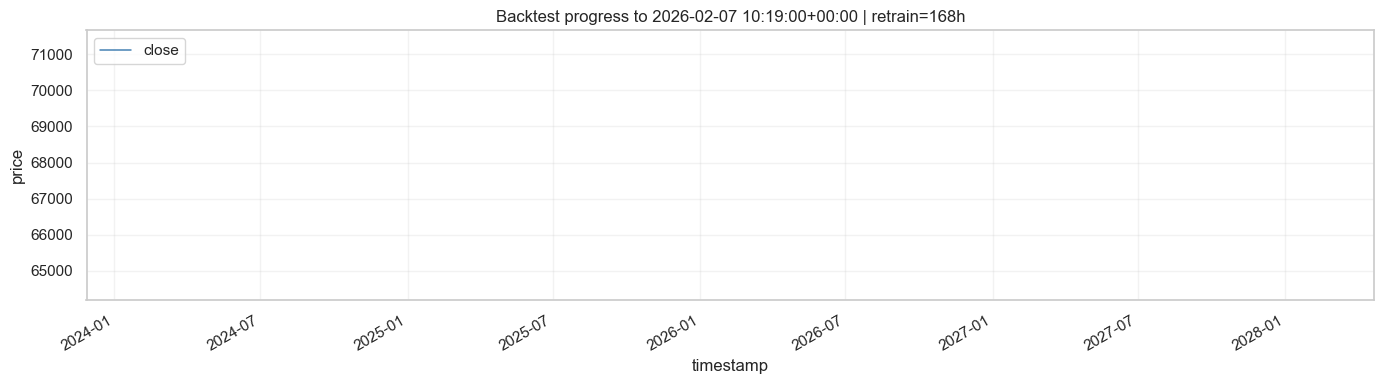

Trade action | ts=2026-02-07 10:20:00+00:00 | action=open_short | side=short | signal_type=trend_short | price=67949.2000 | qty=0.00367701 | realized_pnl=0.00 | free_cash=750.00 | invested_cash=250.00 | current_pnl=-0.15 | grid_pnl=-0.15 | equity=999.85 | reason=enter short: trend aligned and price stays in upper forecast zone ratio=1.00, downside_room=0.035%
Trade action | ts=2026-02-07 11:38:00+00:00 | action=close_short | side=short | signal_type=trend_short | price=67826.7000 | qty=0.00367701 | realized_pnl=0.15 | free_cash=1000.30 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=0.15 | equity=1000.30 | reason=target_exit_price
Trade action | ts=2026-02-07 12:02:00+00:00 | action=open_short | side=short | signal_type=trend_short | price=68259.8000 | qty=0.00366138 | realized_pnl=0.00 | free_cash=750.23 | invested_cash=250.08 | current_pnl=-0.15 | grid_pnl=0.00 | equity=1000.15 | reason=enter short: trend aligned and price stays in upper forecast zone ratio=0.99, downside_room=0.0

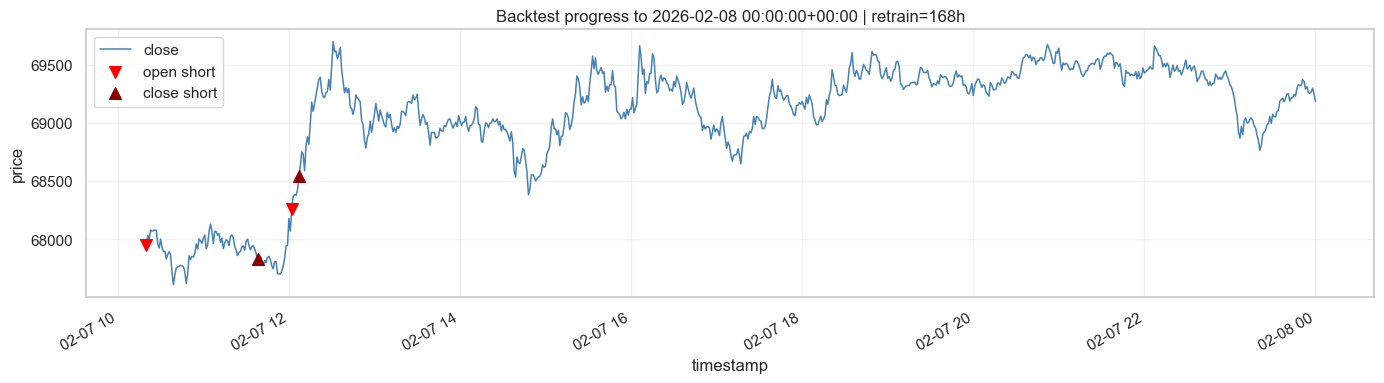

Progress | date=2026-02-09 | step=2246/43014 | trade_actions=4 | free_cash=999.13 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=-1.17 | equity=999.13


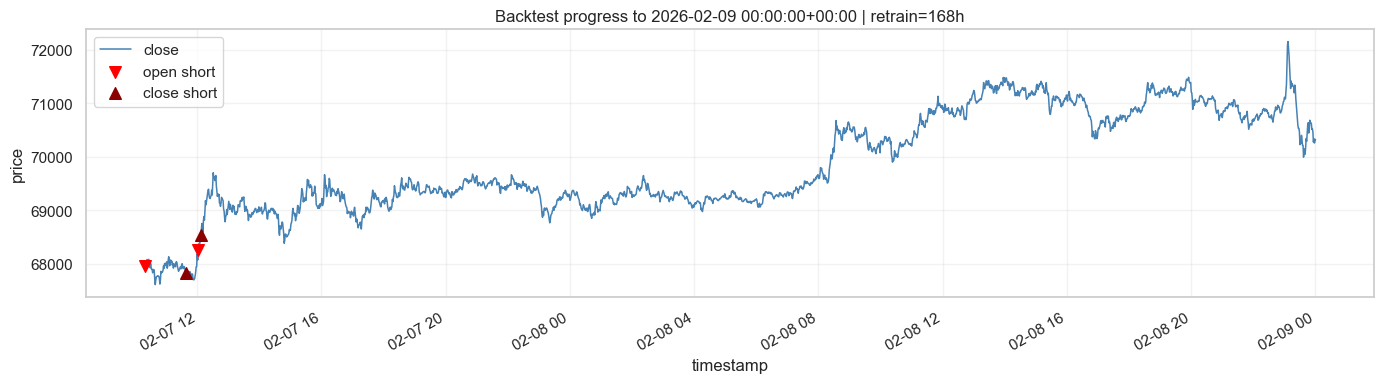

Trade action | ts=2026-02-09 00:18:00+00:00 | action=open_long | side=long | signal_type=trend_long | price=70490.8000 | qty=0.00354134 | realized_pnl=0.00 | free_cash=749.35 | invested_cash=249.78 | current_pnl=-0.15 | grid_pnl=-1.32 | equity=998.98 | reason=enter long: trend aligned and price stays in lower forecast zone ratio=0.00, upside_room=0.032%
Trade action | ts=2026-02-09 00:31:00+00:00 | action=close_long | side=long | signal_type=trend_long | price=70454.2000 | qty=0.00354134 | realized_pnl=-0.43 | free_cash=998.85 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=-1.60 | equity=998.85 | reason=sharp_drop_close_long
Trade action | ts=2026-02-09 01:10:00+00:00 | action=open_short | side=short | signal_type=trend_short | price=70373.4000 | qty=0.00354626 | realized_pnl=0.00 | free_cash=749.14 | invested_cash=249.71 | current_pnl=-0.15 | grid_pnl=-1.75 | equity=998.70 | reason=enter short: trend aligned and price stays in upper forecast zone ratio=0.90, downside_room=0.041%
T

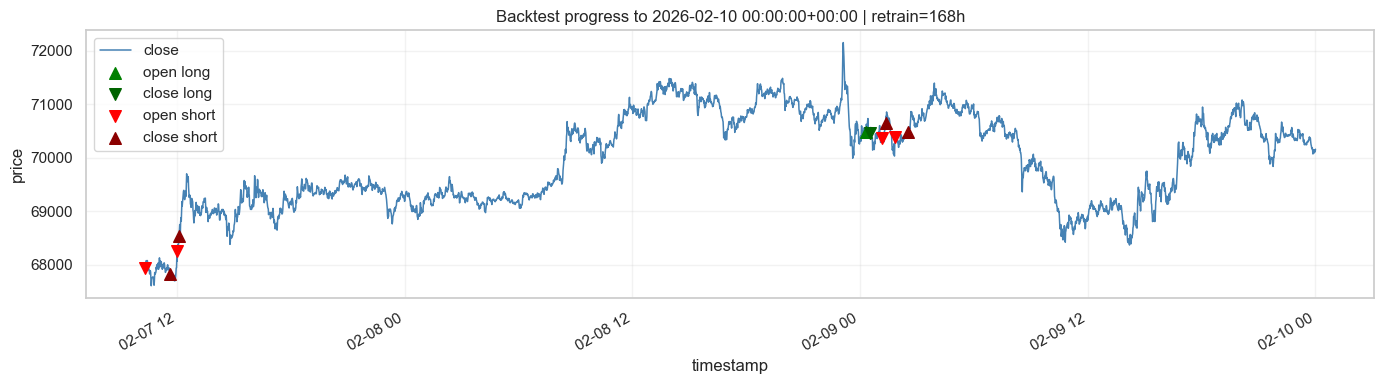

Progress | date=2026-02-11 | step=5113/43014 | trade_actions=10 | free_cash=997.25 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=-3.50 | equity=997.25


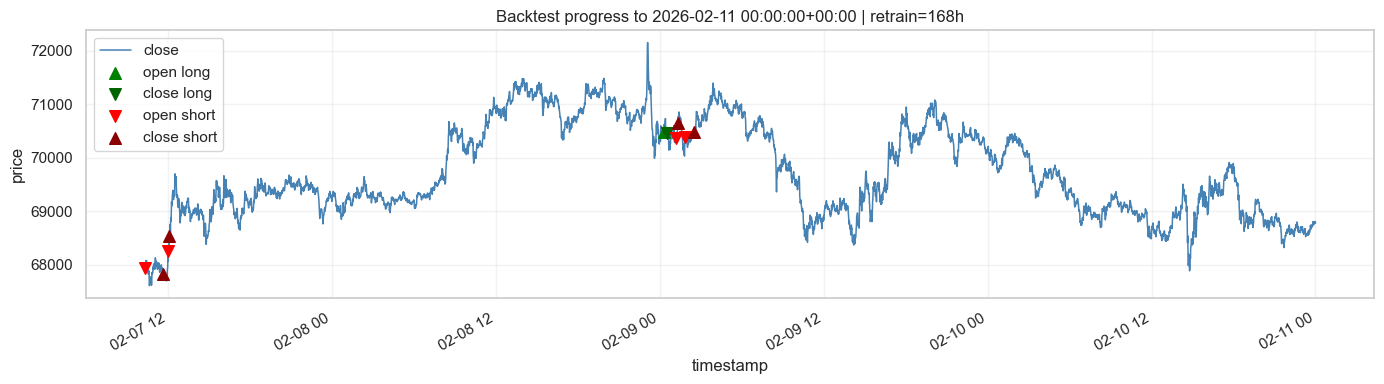

Trade action | ts=2026-02-11 15:34:00+00:00 | action=open_long | side=long | signal_type=trend_long | price=66316.2000 | qty=0.00375719 | realized_pnl=0.00 | free_cash=747.94 | invested_cash=249.31 | current_pnl=-0.15 | grid_pnl=-3.65 | equity=997.10 | reason=enter long: trend aligned and price stays in lower forecast zone ratio=0.00, upside_room=0.034%
Trade action | ts=2026-02-11 15:43:00+00:00 | action=close_long | side=long | signal_type=trend_long | price=66690.3000 | qty=0.00375719 | realized_pnl=1.11 | free_cash=998.50 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=-2.40 | equity=998.50 | reason=sharp_drop_close_long
Trade action | ts=2026-02-11 16:03:00+00:00 | action=open_short | side=short | signal_type=trend_short | price=66448.3000 | qty=0.00375444 | realized_pnl=0.00 | free_cash=748.88 | invested_cash=249.63 | current_pnl=-0.15 | grid_pnl=-2.54 | equity=998.35 | reason=enter short: trend aligned and price stays in upper forecast zone ratio=0.95, downside_room=0.043%
Tr

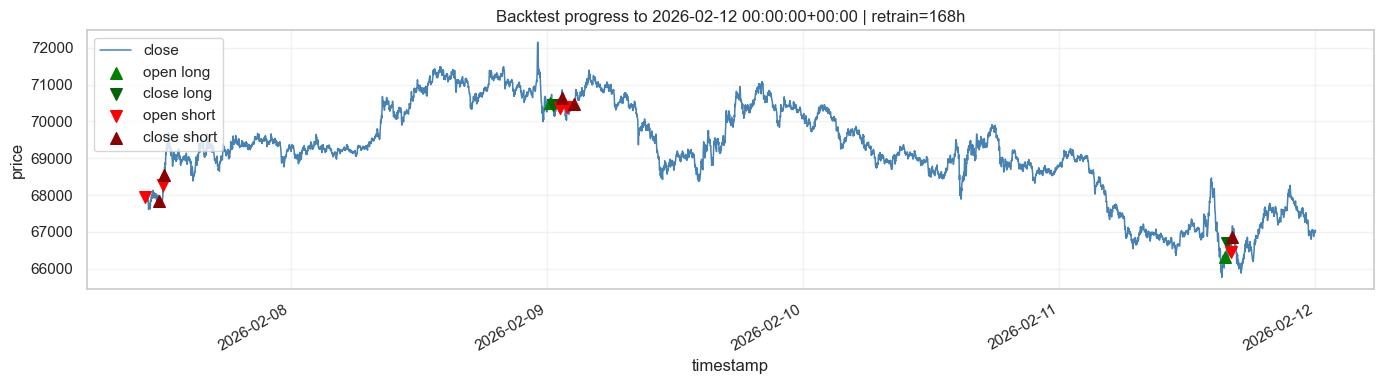

Trade action | ts=2026-02-12 16:56:00+00:00 | action=open_long | side=long | signal_type=trend_long | price=65783.6000 | qty=0.00378586 | realized_pnl=0.00 | free_cash=747.59 | invested_cash=249.20 | current_pnl=-0.15 | grid_pnl=-4.41 | equity=996.64 | reason=enter long: trend aligned and price stays in lower forecast zone ratio=0.00, upside_room=0.037%
Trade action | ts=2026-02-12 17:04:00+00:00 | action=close_long | side=long | signal_type=trend_long | price=65835.2000 | qty=0.00378586 | realized_pnl=-0.10 | free_cash=996.83 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=-4.36 | equity=996.83 | reason=sharp_drop_close_long
Trade action | ts=2026-02-12 17:46:00+00:00 | action=open_long | side=long | signal_type=trend_long | price=65795.1000 | qty=0.00378537 | realized_pnl=0.00 | free_cash=747.63 | invested_cash=249.21 | current_pnl=-0.15 | grid_pnl=-4.51 | equity=996.68 | reason=enter long: trend aligned and price stays in lower forecast zone ratio=0.09, upside_room=0.042%
Trade a

In [ ]:
# Re-run backtest with patched entry logic
backtest_results = []
backtest_meta_rows = []

for retrain_hours in [int(BACKTEST_RETRAIN_EVERY_HOURS)]:
    scenario_trades_df, scenario_meta = _run_backtest_scenario(int(retrain_hours))
    backtest_results.append(scenario_trades_df)
    backtest_meta_rows.append(scenario_meta)

BACKTEST_TRADES_DF = pd.concat(backtest_results, ignore_index=True) if len(backtest_results) > 0 else pd.DataFrame()
BACKTEST_META_DF = pd.DataFrame(backtest_meta_rows).sort_values('retrain_hours').reset_index(drop=True)
BACKTEST_TRADES_VIEW_DF = BACKTEST_TRADES_DF[[
    'retrain_hours', 'timestamp', 'action', 'side', 'signal_type', 'price', 'qty', 'cash_flow', 'realized_pnl', 'free_cash_after', 'equity_after', 'reason'
]].copy() if len(BACKTEST_TRADES_DF) > 0 else pd.DataFrame()

print('\nPatched backtest scenarios:')
display(BACKTEST_META_DF)

if len(BACKTEST_TRADES_VIEW_DF) == 0:
    print('\nTrades: no trading actions were generated for the selected range.')
else:
    print(f'\nTrades shown: last {min(len(BACKTEST_TRADES_VIEW_DF), int(BACKTEST_DISPLAY_MAX_TRADES))} rows.')
    display(BACKTEST_TRADES_VIEW_DF.tail(int(BACKTEST_DISPLAY_MAX_TRADES)).reset_index(drop=True))

In [73]:
# Quick sanity checks for forecast-zone entry gating
sanity_cases = [
    {
        'name': 'reject short near lower zone despite negative bias',
        'current_price': 100.0,
        'horizon_forecasts': {
            'pred_1m': 99.7, 'pred_5m': 99.2, 'pred_10m': 99.0, 'pred_15m': 98.9, 'pred_30m': 98.8, 'pred_60m': 98.7,
            'move_1m_pct': -0.3, 'move_5m_pct': -0.8, 'move_10m_pct': -1.0, 'move_15m_pct': -1.1, 'move_30m_pct': -1.2, 'move_60m_pct': -1.3,
        },
    },
    {
        'name': 'allow short only from upper zone',
        'current_price': 100.0,
        'horizon_forecasts': {
            'pred_1m': 100.1, 'pred_5m': 99.9, 'pred_10m': 99.2, 'pred_15m': 98.9, 'pred_30m': 98.6, 'pred_60m': 98.3,
            'move_1m_pct': 0.1, 'move_5m_pct': -0.1, 'move_10m_pct': -0.8, 'move_15m_pct': -1.1, 'move_30m_pct': -1.4, 'move_60m_pct': -1.7,
        },
    },
    {
        'name': 'allow long only from lower zone',
        'current_price': 100.0,
        'horizon_forecasts': {
            'pred_1m': 99.8, 'pred_5m': 100.2, 'pred_10m': 100.8, 'pred_15m': 101.0, 'pred_30m': 101.4, 'pred_60m': 101.9,
            'move_1m_pct': -0.2, 'move_5m_pct': 0.2, 'move_10m_pct': 0.8, 'move_15m_pct': 1.0, 'move_30m_pct': 1.4, 'move_60m_pct': 1.9,
        },
    },
    {
        'name': 'reject long near upper zone despite positive bias',
        'current_price': 100.0,
        'horizon_forecasts': {
            'pred_1m': 100.3, 'pred_5m': 100.5, 'pred_10m': 100.7, 'pred_15m': 100.8, 'pred_30m': 100.9, 'pred_60m': 101.0,
            'move_1m_pct': 0.3, 'move_5m_pct': 0.5, 'move_10m_pct': 0.7, 'move_15m_pct': 0.8, 'move_30m_pct': 0.9, 'move_60m_pct': 1.0,
        },
    },
]

sanity_rows = []
for case in sanity_cases:
    sanity_signal = _bt_build_trade_signal(case['current_price'], case['horizon_forecasts'])
    sanity_rows.append({
        'case': case['name'],
        'entry_side': sanity_signal['entry_side'],
        'signal_type': sanity_signal['signal_type'],
        'price_zone_ratio': sanity_signal['price_zone_ratio'],
        'upside_room_pct': sanity_signal['safe_upside_room_pct'],
        'downside_room_pct': sanity_signal['safe_downside_room_pct'],
        'entry_reason': sanity_signal['entry_reason'],
    })

display(pd.DataFrame(sanity_rows))

,case,entry_side,signal_type,price_zone_ratio,upside_room_pct,downside_room_pct,entry_reason
0,reject short near lower zone despite negative ...,short,trend_short,1.000000,0.0,1.317123,enter short: trend aligned and price stays in ...
1,allow short only from upper zone,short,trend_short,0.945337,0.1,1.729400,enter short: trend aligned and price stays in ...
2,allow long only from lower zone,long,trend_long,0.095411,1.9,0.200401,enter long: trend aligned and price stays in l...
3,reject long near upper zone despite positive bias,long,trend_long,0.000000,1.0,0.000000,enter long: trend aligned and price stays in l...


In [65]:
BACKTEST_SIGNAL_DIAGNOSTIC_STEP_MINUTES = 60
BACKTEST_SIGNAL_DIAGNOSTIC_USE_CPU = True

if 'history_df' not in globals() or 'catboost_best_params' not in globals():
    print('Signal diagnostic unavailable: сначала запусти ячейки загрузки данных, обучения CatBoost и backtest.')
else:
    diag_step = max(1, int(BACKTEST_SIGNAL_DIAGNOSTIC_STEP_MINUTES))
    retrain_hours = int(BACKTEST_RETRAIN_EVERY_HOURS)
    retrain_minutes = int(retrain_hours * 60)

    end_available_ts = pd.Timestamp(history_df['timestamp'].iloc[-1]).floor('min')
    requested_start_ts = end_available_ts - pd.Timedelta(days=float(BACKTEST_START_DAYS_AGO))
    requested_end_ts = requested_start_ts + pd.Timedelta(days=float(BACKTEST_DURATION_DAYS))
    target_end_ts = min(end_available_ts, requested_end_ts)

    start_candidates = history_df.index[history_df['timestamp'] >= requested_start_ts]
    end_candidates = history_df.index[history_df['timestamp'] <= target_end_ts]

    if len(start_candidates) == 0 or len(end_candidates) == 0:
        raise RuntimeError('Не удалось найти диапазон для signal diagnostic.')

    start_idx = int(start_candidates[0])
    end_idx = int(end_candidates[-1])

    if start_idx < int(BACKTEST_TRAIN_MINUTES):
        raise RuntimeError(
            f'Недостаточно истории для signal diagnostic: {start_idx} < {BACKTEST_TRAIN_MINUTES}.'
        )

    def _diag_forecast_path(model_obj: dict[str, Any], history_series: pd.Series, horizon: int) -> pd.DataFrame:
        history_arr = pd.to_numeric(history_series, errors='coerce').dropna().astype(float).to_numpy()
        context = int(model_obj['context'])
        ret_mean = float(model_obj['ret_mean'])
        ret_std = float(model_obj['ret_std'])
        model = model_obj['model']

        history_log = list(np.log(np.clip(history_arr, 1e-8, None)).astype(float))
        history_ret_norm = list(((np.diff(np.log(np.clip(history_arr, 1e-8, None))) - ret_mean) / ret_std).astype(float))

        rows = []

        for step_idx in range(int(horizon)):
            if len(history_ret_norm) >= context:
                x_ctx = np.asarray(history_ret_norm[-context:], dtype=np.float32)
            else:
                first_val = history_ret_norm[0] if len(history_ret_norm) > 0 else 0.0
                pad = np.full((context - len(history_ret_norm),), first_val, dtype=np.float32)
                x_ctx = np.concatenate([pad, np.asarray(history_ret_norm, dtype=np.float32)])

            pred_ret_norm = float(model.predict(x_ctx.reshape(1, -1))[0])
            pred_ret = pred_ret_norm * ret_std + ret_mean
            pred_ret = float(np.clip(pred_ret, -0.20, 0.20))
            pred_log = float(history_log[-1] + pred_ret)
            pred_price = float(np.exp(pred_log))

            rows.append({'step_minute': int(step_idx + 1), 'pred_price': pred_price})

            history_log.append(pred_log)
            history_ret_norm.append(pred_ret_norm)

        return pd.DataFrame(rows)

    diag_rows = []
    diag_active_model = None

    for idx in range(start_idx, end_idx + 1, diag_step):
        row = history_df.iloc[idx]
        current_ts = pd.Timestamp(row['timestamp']).floor('min')
        current_price = float(row['close'])

        train_window = history_df.iloc[idx - int(BACKTEST_TRAIN_MINUTES) + 1:idx + 1].reset_index(drop=True)
        train_series = train_window['close'].astype(float).reset_index(drop=True)

        needs_refit = diag_active_model is None or current_ts >= diag_active_model['expires_at']

        if needs_refit:
            model_obj = fit_catboost_inference_model(
                train_series,
                context_len=int(catboost_best_params['context_len']),
                depth=int(catboost_best_params['depth']),
                learning_rate=float(catboost_best_params['learning_rate']),
                iterations=int(catboost_best_params['iterations']),
                l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
                use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)) and not BACKTEST_SIGNAL_DIAGNOSTIC_USE_CPU,
            )

            diag_active_model = {
                'model_obj': model_obj,
                'expires_at': current_ts + pd.Timedelta(minutes=retrain_minutes),
            }

        forecast_path_df = _diag_forecast_path(
            diag_active_model['model_obj'],
            history_series=train_series,
            horizon=int(LIVE_FORECAST_HORIZON_MINUTES),
        )

        horizon_forecasts = _bt_extract_horizon_forecasts(
            forecast_path_df=forecast_path_df,
            current_price=current_price,
            horizons=[int(h) for h in LIVE_SIGNAL_HORIZONS],
        )

        trade_signal = _bt_build_trade_signal(
            current_price=current_price,
            horizon_forecasts=horizon_forecasts,
        )

        diag_rows.append({
            'timestamp': current_ts,
            'signal': trade_signal['signal'],
            'signal_type': trade_signal['signal_type'],
            'entry_side': trade_signal['entry_side'],
            'entry_reason': trade_signal['entry_reason'],
            'reason': trade_signal['reason'],
            'move_5m_pct': float(trade_signal['move_5m_pct']),
            'move_10m_pct': float(trade_signal['move_10m_pct']),
            'move_30m_pct': float(trade_signal['move_30m_pct']),
            'move_60m_pct': float(trade_signal['move_60m_pct']),
            'forecast_scale_pct': float(trade_signal['forecast_scale_pct']),
            'required_move_pct': float(trade_signal['required_move_pct']),
            'effective_cost_pct': float(trade_signal['effective_cost_pct']),
            'entry_trigger_move_pct': float(trade_signal['entry_trigger_move_pct']),
            'min_entry_move_pct': float(trade_signal['min_entry_move_pct']),
            'long_bias_score': float(trade_signal['long_bias_score']),
            'short_bias_score': float(trade_signal['short_bias_score']),
            'long_entry_score': float(trade_signal['long_entry_score']),
            'short_entry_score': float(trade_signal['short_entry_score']),
            'long_edge_pct': float(trade_signal['long_edge_pct']),
            'short_edge_pct': float(trade_signal['short_edge_pct']),
            'long_open_trigger': bool(trade_signal['long_open_trigger']),
            'short_open_trigger': bool(trade_signal['short_open_trigger']),
            'long_close_sharp_trigger': bool(trade_signal['long_close_sharp_trigger']),
            'short_close_sharp_trigger': bool(trade_signal['short_close_sharp_trigger']),
            'long_exit_trigger': bool(trade_signal['long_exit_trigger']),
            'short_exit_trigger': bool(trade_signal['short_exit_trigger']),
        })

    BACKTEST_SIGNAL_DIAGNOSTIC_DF = pd.DataFrame(diag_rows)

    median_required_move_pct = float(BACKTEST_SIGNAL_DIAGNOSTIC_DF['entry_trigger_move_pct'].median()) if len(BACKTEST_SIGNAL_DIAGNOSTIC_DF) > 0 else float('nan')

    print(
        f'Signal diagnostic | retrain_every_hours={retrain_hours} | sample_step_minutes={diag_step} | '
        f'adaptive_entry_trigger_median={median_required_move_pct:.3f}'
    )

    if len(BACKTEST_SIGNAL_DIAGNOSTIC_DF) == 0:
        print('Signal diagnostic returned no rows.')
    else:
        signal_counts_df = (
            BACKTEST_SIGNAL_DIAGNOSTIC_DF.groupby(['entry_side', 'signal', 'signal_type'])
            .size()
            .reset_index(name='count')
            .sort_values('count', ascending=False)
            .reset_index(drop=True)
        )

        edge_summary_df = pd.DataFrame([
            {'metric': 'max_move_60m_pct', 'value': float(BACKTEST_SIGNAL_DIAGNOSTIC_DF['move_60m_pct'].max())},
            {'metric': 'min_move_60m_pct', 'value': float(BACKTEST_SIGNAL_DIAGNOSTIC_DF['move_60m_pct'].min())},
            {'metric': 'median_entry_trigger_move_pct', 'value': float(BACKTEST_SIGNAL_DIAGNOSTIC_DF['entry_trigger_move_pct'].median())},
            {'metric': 'median_long_entry_score', 'value': float(BACKTEST_SIGNAL_DIAGNOSTIC_DF['long_entry_score'].median())},
            {'metric': 'median_short_entry_score', 'value': float(BACKTEST_SIGNAL_DIAGNOSTIC_DF['short_entry_score'].median())},
            {'metric': 'median_long_bias_score', 'value': float(BACKTEST_SIGNAL_DIAGNOSTIC_DF['long_bias_score'].median())},
            {'metric': 'median_short_bias_score', 'value': float(BACKTEST_SIGNAL_DIAGNOSTIC_DF['short_bias_score'].median())},
            {'metric': 'long_entry_recommendations', 'value': int((BACKTEST_SIGNAL_DIAGNOSTIC_DF['entry_side'] == 'long').sum())},
            {'metric': 'short_entry_recommendations', 'value': int((BACKTEST_SIGNAL_DIAGNOSTIC_DF['entry_side'] == 'short').sum())},
            {'metric': 'long_open_trigger_hits', 'value': int(BACKTEST_SIGNAL_DIAGNOSTIC_DF['long_open_trigger'].sum())},
            {'metric': 'short_open_trigger_hits', 'value': int(BACKTEST_SIGNAL_DIAGNOSTIC_DF['short_open_trigger'].sum())},
            {'metric': 'sharp_long_close_hits', 'value': int(BACKTEST_SIGNAL_DIAGNOSTIC_DF['long_close_sharp_trigger'].sum())},
            {'metric': 'sharp_short_close_hits', 'value': int(BACKTEST_SIGNAL_DIAGNOSTIC_DF['short_close_sharp_trigger'].sum())},
            {'metric': 'long_exit_triggers', 'value': int(BACKTEST_SIGNAL_DIAGNOSTIC_DF['long_exit_trigger'].sum())},
            {'metric': 'short_exit_triggers', 'value': int(BACKTEST_SIGNAL_DIAGNOSTIC_DF['short_exit_trigger'].sum())},
            {'metric': 'rows_checked', 'value': int(len(BACKTEST_SIGNAL_DIAGNOSTIC_DF))},
        ])

        display(edge_summary_df)
        display(signal_counts_df.head(20))

        top_move_rows_df = (
            BACKTEST_SIGNAL_DIAGNOSTIC_DF.assign(abs_move_60m_pct=lambda df: df['move_60m_pct'].abs())
            .sort_values('abs_move_60m_pct', ascending=False)
            .head(20)
            .reset_index(drop=True)
        )

        print('\nTop |move_60m_pct| rows:')
        display(top_move_rows_df[[
            'timestamp', 'entry_side', 'signal', 'signal_type', 'entry_reason', 'move_5m_pct', 'move_10m_pct', 'move_30m_pct',
            'move_60m_pct', 'entry_trigger_move_pct', 'min_entry_move_pct', 'long_entry_score', 'short_entry_score',
            'long_bias_score', 'short_bias_score', 'long_open_trigger', 'short_open_trigger',
            'long_close_sharp_trigger', 'short_close_sharp_trigger', 'long_exit_trigger', 'short_exit_trigger', 'long_edge_pct', 'short_edge_pct'
        ]])

        if 'BACKTEST_TRADES_DF' in globals() and len(BACKTEST_TRADES_DF) == 0:
            print('\nПочему 0 сделок:')
            print(
                f'- Медианный trigger = {float(BACKTEST_SIGNAL_DIAGNOSTIC_DF["entry_trigger_move_pct"].median()):.3f}%, '
                f'long-рекомендаций = {int((BACKTEST_SIGNAL_DIAGNOSTIC_DF["entry_side"] == "long").sum())}, '
                f'short-рекомендаций = {int((BACKTEST_SIGNAL_DIAGNOSTIC_DF["entry_side"] == "short").sum())}.'
            )
            print(
                f'- Медианный long_entry_score = {float(BACKTEST_SIGNAL_DIAGNOSTIC_DF["long_entry_score"].median()):.3f}, '
                f'median short_entry_score = {float(BACKTEST_SIGNAL_DIAGNOSTIC_DF["short_entry_score"].median()):.3f}.'
            )
            print('- Если сделок всё ещё мало, нужно дальше ослаблять входной фильтр или улучшать саму модель, а не дробить свечи.')

Signal diagnostic | retrain_every_hours=168 | sample_step_minutes=60 | adaptive_entry_trigger_median=0.030


,metric,value
0,max_move_60m_pct,0.090918
1,min_move_60m_pct,-0.090074
2,median_entry_trigger_move_pct,0.030000
3,median_long_entry_score,0.000000
4,median_short_entry_score,0.699764
5,median_long_bias_score,-0.696910
6,median_short_bias_score,0.699764
7,long_entry_recommendations,5.000000
8,short_entry_recommendations,279.000000
9,long_open_trigger_hits,5.000000


,entry_side,signal,signal_type,count
0,flat,hold,none,433
1,short,hold,none,227
2,short,short,trend_short,52
3,long,hold,none,4
4,long,long,trend_long,1



Top |move_60m_pct| rows:


,timestamp,entry_side,signal,signal_type,entry_reason,move_5m_pct,move_10m_pct,move_30m_pct,move_60m_pct,entry_trigger_move_pct,min_entry_move_pct,long_entry_score,short_entry_score,long_bias_score,short_bias_score,long_open_trigger,short_open_trigger,long_close_sharp_trigger,short_close_sharp_trigger,long_exit_trigger,short_exit_trigger,long_edge_pct,short_edge_pct
0,2026-02-11 15:58:00+00:00,long,hold,none,enter long: stable positive 10m/30m/60m bias,0.020295,0.006501,0.081152,0.090918,0.060864,0.03,1.241931,0.000000,1.241931,0.000000,True,False,False,True,False,True,0.060486,-0.121349
1,2026-03-01 22:42:00+00:00,short,short,trend_short,enter short: stable negative 10m/30m/60m bias,-0.008225,-0.019472,-0.057984,-0.090074,0.043488,0.03,0.000000,1.381518,-1.381518,1.381518,False,True,True,False,True,False,-0.111818,0.068330
2,2026-02-08 23:35:00+00:00,short,short,trend_short,enter short: stable negative 10m/30m/60m bias,-0.012881,-0.033958,-0.088486,-0.089046,0.066364,0.03,0.000000,1.356739,-1.356739,1.356739,False,True,True,False,True,False,-0.122228,0.055864
3,2026-03-03 15:58:00+00:00,short,short,trend_short,enter short: stable negative 10m/30m/60m bias,-0.007711,-0.015817,-0.040224,-0.086854,0.030168,0.03,0.000000,1.426713,-1.426713,1.426713,False,True,True,False,True,False,-0.101938,0.071770
4,2026-03-02 17:54:00+00:00,short,short,trend_short,enter short: stable negative 10m/30m/60m bias,-0.020421,-0.046981,-0.061369,-0.083444,0.046026,0.03,0.000000,1.500000,-1.500000,1.500000,False,True,True,False,True,False,-0.106457,0.060431
5,2026-03-03 18:00:00+00:00,short,short,trend_short,enter short: stable negative 10m/30m/60m bias,-0.014144,-0.027318,-0.064565,-0.080314,0.048424,0.03,0.000000,1.466838,-1.466838,1.466838,False,True,True,False,True,False,-0.104526,0.056102
6,2026-03-02 14:48:00+00:00,short,hold,none,enter short: stable negative 10m/30m/60m bias,-0.008793,-0.005064,-0.027240,-0.077137,0.030000,0.03,0.000000,1.234379,-1.234379,1.234379,False,True,True,False,True,False,-0.092137,0.062137
7,2026-03-04 16:11:00+00:00,short,hold,none,enter short: stable negative 10m/30m/60m bias,-0.020391,-0.022423,0.000045,-0.077060,0.030000,0.03,0.000747,1.050000,-1.049253,1.050000,False,True,True,False,True,False,-0.092060,0.062060
8,2026-03-04 10:06:00+00:00,short,short,trend_short,enter short: stable negative 10m/30m/60m bias,-0.014575,-0.018359,-0.028475,-0.074926,0.030000,0.03,0.000000,1.495746,-1.495746,1.495746,False,True,True,False,True,False,-0.089926,0.059926
9,2026-03-01 23:43:00+00:00,short,hold,none,enter short: stable negative 10m/30m/60m bias,0.006853,0.007128,-0.039955,-0.074427,0.030000,0.03,0.204307,1.050000,-0.845693,1.050000,False,True,False,False,False,False,-0.089427,0.059427


## 8) Summary по backtest

Сводка считает метрики по закрытым сделкам и сравнивает сценарии переобучения модели, например каждые `24` и `168` часов.

Базовые метрики: количество закрытых сделок, winrate, суммарный PnL, ending equity.

Дополнительно: средний PnL на сделку, gross profit, gross loss и profit factor.

In [64]:
if 'BACKTEST_TRADES_DF' not in globals() or len(BACKTEST_TRADES_DF) == 0:

    BACKTEST_SUMMARY_DF = pd.DataFrame()

    print('Backtest summary unavailable: сначала запусти Cell 15.')

else:

    closed_trades_df = BACKTEST_TRADES_DF[
        BACKTEST_TRADES_DF['action'].astype(str).str.startswith('close_')
    ].copy()

    if len(closed_trades_df) == 0:

        BACKTEST_SUMMARY_DF = pd.DataFrame(columns=[
            'retrain_hours',
            'closed_trades',
            'wins',
            'losses',
            'winrate_pct',
            'total_realized_pnl',
            'avg_realized_pnl',
            'gross_profit',
            'gross_loss',
            'profit_factor',
            'ending_equity',
        ])

        print('Closed trades: 0. Модель отработала диапазон, но точек закрытия позиции не появилось.')

    else:

        closed_trades_df['realized_pnl'] = pd.to_numeric(closed_trades_df['realized_pnl'], errors='coerce')

        summary_rows = []

        for retrain_hours, group_df in closed_trades_df.groupby('retrain_hours', dropna=False):

            pnl = group_df['realized_pnl'].dropna().astype(float)

            wins = int((pnl > 0).sum())

            losses = int((pnl < 0).sum())

            closed_count = int(len(pnl))

            gross_profit = float(pnl[pnl > 0].sum()) if closed_count > 0 else 0.0

            gross_loss = float(-pnl[pnl < 0].sum()) if closed_count > 0 else 0.0

            ending_equity = float(group_df['equity_after'].dropna().iloc[-1]) if group_df['equity_after'].notna().any() else float('nan')

            summary_rows.append({
                'retrain_hours': int(retrain_hours),
                'closed_trades': closed_count,
                'wins': wins,
                'losses': losses,
                'winrate_pct': float(wins / closed_count * 100.0) if closed_count > 0 else float('nan'),
                'total_realized_pnl': float(pnl.sum()) if closed_count > 0 else 0.0,
                'avg_realized_pnl': float(pnl.mean()) if closed_count > 0 else float('nan'),
                'gross_profit': gross_profit,
                'gross_loss': gross_loss,
                'profit_factor': float(gross_profit / gross_loss) if gross_loss > 0 else float('inf') if gross_profit > 0 else float('nan'),
                'ending_equity': ending_equity,
            })

        BACKTEST_SUMMARY_DF = pd.DataFrame(summary_rows).sort_values(
            ['total_realized_pnl', 'winrate_pct'], ascending=[False, False]
        ).reset_index(drop=True)

        best_row = BACKTEST_SUMMARY_DF.iloc[0].to_dict()

        print('Backtest summary ready.')
        print(
            f"Best scenario: retrain_every={int(best_row['retrain_hours'])}h | "
            f"closed_trades={int(best_row['closed_trades'])} | "
            f"winrate={float(best_row['winrate_pct']):.2f}% | "
            f"total_pnl={float(best_row['total_realized_pnl']):.2f} | "
            f"ending_equity={float(best_row['ending_equity']):.2f}"
        )

    display(BACKTEST_SUMMARY_DF)

    if 'BACKTEST_META_DF' in globals() and len(BACKTEST_META_DF) > 0:

        BACKTEST_COMPARE_DF = BACKTEST_META_DF.merge(
            BACKTEST_SUMMARY_DF,
            on='retrain_hours',
            how='left',
            suffixes=('_scenario', '_summary'),
        ).sort_values('retrain_hours').reset_index(drop=True)

        compare_cols = [
            'retrain_hours',
            'requested_start_ts',
            'requested_end_ts',
            'actual_start_ts',
            'actual_end_ts',
            'effective_duration_days',
            'eval_step_minutes',
            'trade_actions',
            'closed_trades',
            'winrate_pct',
            'total_realized_pnl',
            'profit_factor',
            'ending_equity',
        ]

        print('\nScenario comparison:')
        display(BACKTEST_COMPARE_DF[compare_cols])

    extra_ideas = pd.DataFrame(
        [
            {'idea': 'Max drawdown', 'why': 'Показывает худшую просадку капитала, а не только финальный PnL.'},
            {'idea': 'Average trade duration', 'why': 'Показывает, насколько долго позиции висят до закрытия.'},
            {'idea': 'PnL by signal type', 'why': 'Сравнивает trend_long / buy_dip / trend_short / sell_rally.'},
            {'idea': 'Commission and slippage', 'why': 'Делает бектест ближе к реальной торговле.'},
            {'idea': 'Monthly or weekly slices', 'why': 'Показывает стабильность стратегии на разных участках рынка.'},
        ]
    )

    print('\nNext useful metrics to add:')
    display(extra_ideas)

Backtest summary ready.
Best scenario: retrain_every=168h | closed_trades=23 | winrate=30.43% | total_pnl=-10.74 | ending_equity=992.70


,retrain_hours,closed_trades,wins,losses,winrate_pct,total_realized_pnl,avg_realized_pnl,gross_profit,gross_loss,profit_factor,ending_equity
0,168,23,7,16,30.434783,-10.735801,-0.466774,5.128039,15.86384,0.323253,992.70339



Scenario comparison:


KeyError: "['closed_trades', 'ending_equity'] not in index"

In [60]:
# Quick strategy diagnostics from latest backtest results
if 'BACKTEST_TRADES_DF' in globals() and len(BACKTEST_TRADES_DF) > 0:
    _tr = BACKTEST_TRADES_DF.copy()
    _close = _tr[_tr['action'].astype(str).str.startswith('close_')].copy()
    _close['realized_pnl'] = pd.to_numeric(_close['realized_pnl'], errors='coerce')

    print('--- Close trades summary ---')
    print(f"closed_trades={len(_close)}")
    if len(_close) > 0:
        wins = int((_close['realized_pnl'] > 0).sum())
        losses = int((_close['realized_pnl'] < 0).sum())
        print(f"wins={wins} losses={losses} winrate={wins / max(len(_close), 1):.2%}")
        print(f"total_realized_pnl={_close['realized_pnl'].sum():.2f}")
        print(f"avg_win={_close.loc[_close['realized_pnl'] > 0, 'realized_pnl'].mean():.4f}")
        print(f"avg_loss={_close.loc[_close['realized_pnl'] < 0, 'realized_pnl'].mean():.4f}")

        print('\n--- By side ---')
        side_stats = _close.groupby('side')['realized_pnl'].agg(['count', 'sum', 'mean'])
        display(side_stats)

        print('\n--- Close reason stats ---')
        reason_stats = _close.groupby('reason')['realized_pnl'].agg(['count', 'sum', 'mean']).sort_values('sum')
        display(reason_stats)

        print('\n--- Signal type stats ---')
        sig_stats = _close.groupby('signal_type')['realized_pnl'].agg(['count', 'sum', 'mean']).sort_values('sum')
        display(sig_stats)
else:
    print('BACKTEST_TRADES_DF is empty or not found. Run backtest cell first.')

BACKTEST_TRADES_DF is empty or not found. Run backtest cell first.
